# xCounter — Predição de Sucesso em Contra-Ataques com Prior Físico do Football Manager 2023

**Disciplina:** COE609 - Ciência de Dados Aplicada ao Futebol (UFRJ, 2026.1)

## Objetivo

Construir um modelo preditivo de sucesso de contra-ataques (**xCounter**) substituindo
features físicas de tracking contínuo por um *prior* estático de atributos por jogador
extraído do **Football Manager 2023**.

**Hipótese central:** essa substituição preserva poder preditivo significativo, viabilizando
a metodologia em contextos sem dados de tracking contínuo.

## Pipeline

| Etapa | Descrição |
|-------||-----------|
| 1 | Carregamento dos dados (eventos + StatsBomb 360) |
| 2 | Identificação de cadeias de contra-ataque |
| 3 | Extração de features espaciais via Freeze Frame 360 |
| 4 | Integração com atributos físicos do FM2023 |
| 5 | Escalonamento para as 64 partidas da Copa do Mundo FIFA 2022 |
| 6 | Modelagem comparativa: Baseline Espacial vs. Espacial + Físico |


In [135]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os

from mplsoccer import Sbopen, Pitch
from unidecode import unidecode

print("Bibliotecas carregadas com sucesso.")
import mplsoccer
print(f"  pandas {pd.__version__} | numpy {np.__version__} | mplsoccer {mplsoccer.__version__}")

Bibliotecas carregadas com sucesso.
  pandas 2.2.3 | numpy 2.1.3 | mplsoccer 1.6.1


## 1. Parâmetros e Configuração

Todos os critérios operacionais estão centralizados no bloco `config` para facilitar ajustes e reprodutibilidade.


In [136]:
# ==================
# PARÂMETROS GLOBAIS
# ==================
MATCH_ID       = 3857273   # Copa do Mundo 2022: País de Gales × Irã
COMPETITION_ID = 43        # FIFA World Cup
SEASON_ID      = 106       # 2022

GOAL_X = 120.0  # Coordenada x do gol adversário (sistema StatsBomb: 0-120)
GOAL_Y = 40.0   # Coordenada y do centro do gol

# Atributos físicos do FM2023 a incorporar
FM_ATTRS    = ['Pac', 'Acc', 'Sta', 'Str', 'Agi', 'Bal', 'Jum']
FM_CSV_PATH = 'fm2023_copa_2022.csv'

# ============================================================
# BLOCO DE CONFIGURAÇÃO — xCounter
# Altere apenas aqui para análise de sensibilidade.
# Não toque no corpo das funções.
# ============================================================
config = {
    # --- Zona de início válida para a recuperação ---
    # Opções: "metade_defensiva" (x < 60), "terco_defensivo" (x < 40),
    #         "campo_todo" (qualquer x), "custom" (x < zona_recuperacao_x_max)
    # Sistema de coordenadas StatsBomb: eixo x de 0 a 120; equipe que
    # recupera ataca em direção a x=120.
    "zona_recuperacao":       "metade_defensiva",
    "zona_recuperacao_x_max": 0,  # usado só se zona_recuperacao == "custom"

    # --- Janela de análise pós-recuperação ---
    "max_eventos_apos":          15,   # eventos a olhar após a recuperação (5→original)
    "max_tempo_s":               60,  # duração máxima da cadeia em segundos
    "progressao_vertical_min_m": 30,  # ganho mínimo em x (metros) para qualificar

    # --- Condições de quebra da cadeia (avaliadas nesta ordem) ---
    # 1. fim_periodo: period do próx. evento != period do início da cadeia
    # 2. perda_posse: equipe do próx. evento != equipe recuperadora
    # 3. max_tempo_s / max_eventos_apos: sempre verificados (não são flags)
    # 4. falta: próx. evento é Foul Won ou Foul Committed (depois de adicionar)
    # 5. chute: próx. evento é Shot (depois de adicionar)
    "quebrar_em_fim_periodo":  False,  # False → comportamento original
    "quebrar_em_perda_posse":  True,
    "quebrar_em_falta":        False,  # False → comportamento original
    "quebrar_em_chute":        True,

    # --- Eventos que iniciam um contra-ataque ---
    "eventos_inicio": ["Ball Recovery", "Interception", "Duel"],

    # --- Critério de sucesso ---
    # "qualquer_chute" : sucesso se a cadeia termina em qualquer Shot
    # "xg_threshold"   : sucesso se Shot com shot_statsbomb_xg >= xg_threshold
    # "gol"            : sucesso somente se o Shot resultou em gol
    "criterio_sucesso": "qualquer_chute",
    "xg_threshold":     0.10,
}


def validar_config(cfg):
    """Valida parâmetros do config; levanta ValueError com mensagem clara."""
    zonas_validas = {"metade_defensiva", "terco_defensivo", "campo_todo", "custom"}
    if cfg["zona_recuperacao"] not in zonas_validas:
        raise ValueError(f"zona_recuperacao deve ser uma de {zonas_validas}.")
    if cfg["zona_recuperacao"] == "custom" and cfg.get("zona_recuperacao_x_max") is None:
        raise ValueError("zona_recuperacao='custom' requer zona_recuperacao_x_max != None.")
    criterios_validos = {"qualquer_chute", "xg_threshold", "gol"}
    if cfg["criterio_sucesso"] not in criterios_validos:
        raise ValueError(f"criterio_sucesso deve ser um de {criterios_validos}.")
    if cfg["criterio_sucesso"] == "xg_threshold" and cfg.get("xg_threshold") is None:
        raise ValueError("criterio_sucesso='xg_threshold' requer xg_threshold definido.")


validar_config(config)

# Aliases para compatibilidade com as células de visualização
XG_THRESHOLD             = config["xg_threshold"]
CRIT_TEMPO_MAX_S         = config["max_tempo_s"]
CRIT_DIST_VERTICAL_MIN_M = config["progressao_vertical_min_m"]
CRIT_MAX_EVENTOS         = config["max_eventos_apos"]

print("Parâmetros configurados e validados.")
print(f"  Match ID: {MATCH_ID} | Zona: {config['zona_recuperacao']} | "
      f"xG threshold: {XG_THRESHOLD}")
print(f"  Tempo máx: {CRIT_TEMPO_MAX_S}s | Progressão mín: "
      f"{CRIT_DIST_VERTICAL_MIN_M}m | Eventos máx pós-rec.: {CRIT_MAX_EVENTOS}")


Parâmetros configurados e validados.
  Match ID: 3857273 | Zona: metade_defensiva | xG threshold: 0.1
  Tempo máx: 60s | Progressão mín: 30m | Eventos máx pós-rec.: 15


## 2. Etapa 1 — Carregamento de Dados

Inicializa o parser StatsBomb (`Sbopen`) e carrega os dados de referência. O objeto `parser` é global e reutilizado por `processar_partida` e `rodar_analise_sensibilidade` ao longo do pipeline.

- `parser.event(match_id)` → 4 DataFrames: eventos, relacionados, freeze de chutes, táticas
- `parser.frame(match_id)` → 2 DataFrames: `df_360` (posições por evento) e `df_visible` (área rastreada)
- `parser.match(competition_id, season_id)` → metadados de todas as partidas da competição

O `df_360` tem colunas `[teammate, actor, keeper, match_id, id, x, y]` — uma linha por jogador visível em cada evento com cobertura 360.


In [137]:
print("=== Etapa 1: Carregamento dos Dados ===\n")
parser = Sbopen()

# Eventos e táticas
df_event, df_related, df_freeze_shots, df_tactics = parser.event(MATCH_ID)

# Freeze frames 360 de todos os eventos com cobertura
df_360, df_visible = parser.frame(MATCH_ID)

# Metadados da partida
df_match_info = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_row     = df_match_info[df_match_info['match_id'] == MATCH_ID].iloc[0]

home_team  = match_row['home_team_name']
away_team  = match_row['away_team_name']
home_score = int(match_row['home_score'])
away_score = int(match_row['away_score'])

print(f"Partida:  {home_team}  {home_score} x {away_score}  {away_team}")
print(f"Data:     {str(match_row['match_date'])[:10]}")
print(f"\nEventos carregados:          {len(df_event):,}")
print(f"Linhas no DataFrame 360:     {len(df_360):,}")
print(f"Eventos com frame 360:       {df_360['id'].nunique():,}")
print(f"\nTipos de evento mais comuns:")
print(df_event['type_name'].value_counts().head(20).to_string())

=== Etapa 1: Carregamento dos Dados ===

Partida:  Wales  0 x 2  Iran
Data:     2022-11-25

Eventos carregados:          3,133
Linhas no DataFrame 360:     42,319
Eventos com frame 360:       2,768

Tipos de evento mais comuns:
type_name
Pass               922
Ball Receipt       760
Carry              645
Pressure           251
Ball Recovery      120
Duel                70
Clearance           51
Block               46
Goal Keeper         38
Shot                31
Miscontrol          28
Dribble             27
Interception        25
Foul Committed      19
Foul Won            19
Dispossessed        16
Dribbled Past       13
Injury Stoppage     10
Substitution         9
50/50                8


## 3. Etapa 2 — Identificação de Contra-Ataques

Uma cadeia é classificada como **contra-ataque** se atende simultaneamente a:

| Critério | Parâmetro |
|----------||-----------|
| Início: Ball Recovery, Interception ou Duel vencido | `zona_recuperacao = "metade_defensiva"` (x < 60) |
| Duração máxima | `max_tempo_s = 15s` |
| Progressão mínima no eixo x | `progressao_vertical_min_m = 30m` |
| Nº máximo de eventos pós-recuperação | `max_eventos_apos = 10` |

**Rótulo binário:**
- `sucesso = 1` → cadeia termina em chute com `shot_statsbomb_xg ≥ xg_threshold`
- `sucesso = 0` → caso contrário (inclui cadeias sem finalização)

A função `rodar_analise_sensibilidade` (definida a seguir) permite comparar o impacto de diferentes parametrizações — ver Apêndice para demonstração.


In [138]:
# ============================================================
# ETAPA 2: IDENTIFICAÇÃO DE CONTRA-ATAQUES
# ============================================================

# Eventos do adversário que NÃO contam como perda de posse efetiva.
# Aparecem como team_name diferente no df_event, mas a posse 'lógica'
# permanece com a equipe atacante (ex.: Pressure interrompe a cadeia
# antes do chute, deflacionando terminou_chute = True).
EVENTOS_DEFENSIVOS_NEUTROS = {
    "Pressure",
    "Block",
    "Clearance",
    "50/50",
    "Shield",
    "Error",
}

def _resolver_x_max_zona(cfg):
    """Traduz zona_recuperacao para o limite numérico em x."""
    zona = cfg["zona_recuperacao"]
    if zona == "metade_defensiva":
        return 60.0
    if zona == "terco_defensivo":
        return 40.0
    if zona == "campo_todo":
        return float("inf")
    return float(cfg["zona_recuperacao_x_max"])  # custom


def identificar_contra_ataques(df_event, cfg):
    """
    Identifica cadeias de contra-ataque a partir do dataframe de eventos.
    Recebe `cfg` (dict de config) com todos os critérios operacionais.

    Ordem de avaliação das condições de quebra do loop interno:
      ANTES de adicionar o evento à cadeia:
        1. quebrar_em_fim_periodo  — period diferente do início
        2. quebrar_em_perda_posse  — equipe diferente da recuperadora
        3. max_tempo_s             — sempre verificado
      APÓS adicionar o evento à cadeia:
        4. quebrar_em_falta        — Foul Won / Foul Committed
        5. quebrar_em_chute        — Shot

    Retorna lista de dicts com metadados de cada cadeia qualificada.
    """
    x_max_zona       = _resolver_x_max_zona(cfg)
    max_eventos      = cfg["max_eventos_apos"]
    max_tempo        = cfg["max_tempo_s"]
    prog_min         = cfg["progressao_vertical_min_m"]
    eventos_inicio   = set(cfg["eventos_inicio"])
    criterio_sucesso = cfg["criterio_sucesso"]
    xg_thr           = cfg.get("xg_threshold", 0.10)

    contra_ataques = []
    df = df_event.sort_values(["period", "minute", "second", "index"]).reset_index(drop=True)

    i = 0
    while i < len(df):
        ev    = df.iloc[i]
        x_ev  = ev.get("x")
        if pd.isna(x_ev):
            i += 1
            continue

        eh_rec  = ev["type_name"] in eventos_inicio
        na_zona = float(x_ev) < x_max_zona

        # Duels: apenas se foram vencidos
        if ev["type_name"] == "Duel":
            outcome = str(ev.get("outcome_name", "")).lower()
            eh_rec  = "won" in outcome

        if eh_rec and na_zona:
            t0        = ev["minute"] * 60 + ev["second"]
            equipe    = ev["team_name"]
            period_ev = ev["period"]
            cadeia    = [ev]

            j = i + 1
            while j < len(df) and len(cadeia) <= max_eventos:
                prox = df.iloc[j]
                t    = prox["minute"] * 60 + prox["second"]

                # Condições de quebra ANTES de adicionar (ordem 1 → 3)
                if cfg["quebrar_em_fim_periodo"] and prox["period"] != period_ev:
                    break
                if cfg["quebrar_em_perda_posse"]:
                    mudou_equipe = prox["team_name"] != equipe
                    eh_defensivo_neutro = prox["type_name"] in EVENTOS_DEFENSIVOS_NEUTROS
                    if mudou_equipe and not eh_defensivo_neutro:
                        break
                if (t - t0) > max_tempo:
                    break

                cadeia.append(prox)
                j += 1

                # Condições de quebra APÓS adicionar (ordem 4 → 5)
                if cfg["quebrar_em_falta"] and prox["type_name"] in {"Foul Won", "Foul Committed"}:
                    break
                if cfg["quebrar_em_chute"] and prox["type_name"] == "Shot":
                    break

            # Calcular métricas da cadeia
            x_ini   = float(ev["x"])
            ultimo  = cadeia[-1]
            x_fim   = ultimo.get("end_x")
            if pd.isna(x_fim):
                x_fim = ultimo.get("x", x_ini)
            x_fim   = float(x_fim) if not pd.isna(x_fim) else x_ini

            prog           = x_fim - x_ini
            terminou_chute = (ultimo["type_name"] == "Shot")
            xg_final       = float(ultimo.get("shot_statsbomb_xg") or 0) if terminou_chute else 0.0
            t_final        = ultimo["minute"] * 60 + ultimo["second"]
            duracao_s      = float(t_final - t0)

            # Critério de sucesso
            if criterio_sucesso == "qualquer_chute":
                sucesso = terminou_chute
            elif criterio_sucesso == "gol":
                sucesso = terminou_chute and str(ultimo.get("outcome_name", "")).lower() == "goal"
            else:  # xg_threshold
                sucesso = bool(terminou_chute and xg_final >= xg_thr)

            if prog >= prog_min:
                contra_ataques.append({
                    "id_inicio":      cadeia[0]["id"],
                    "player_id":      cadeia[0].get("player_id"),
                    "player_name":    str(cadeia[0].get("player_name", "")),
                    "team":           equipe,
                    "period":         int(cadeia[0]["period"]),
                    "minute":         int(cadeia[0]["minute"]),
                    "second":         int(cadeia[0]["second"]),
                    "tipo_inicio":    cadeia[0]["type_name"],
                    "x_inicio":       x_ini,
                    "y_inicio":       float(cadeia[0].get("y") or 40.0),
                    "num_eventos":    len(cadeia),
                    "progressao_x":   float(prog),
                    "duracao_s":      duracao_s,
                    "terminou_chute": terminou_chute,
                    "xg_final":       xg_final,
                    "sucesso":        bool(sucesso),
                })
        i += 1

    return contra_ataques


print("Funções _resolver_x_max_zona e identificar_contra_ataques definidas.")


Funções _resolver_x_max_zona e identificar_contra_ataques definidas.


## 4. Etapa 3 — Features Espaciais do Freeze Frame 360

Para cada cadeia de contra-ataque, recupera-se o freeze frame do evento de início e calculam-se 7 features de posicionamento:

| Feature | Cálculo |
|---------||---------|
| `dist_gol_defensor_proximo` | Dist. Euclidiana: gol → defensor mais avançado (maior `x` entre oponentes) |
| `dist_gol_atacante_avancado` | Dist. Euclidiana: gol → atacante mais avançado (maior `x` entre companheiros) |
| `diferencial_profundidade` | `x_atacante_avancado − x_defensor_mais_avancado` |
| `num_defensores_entre_bola_gol` | Oponentes com `x > x_bola` |
| `largura_linha_defensiva` | Spread em `y` dos 3 defensores mais avançados |
| `dist_bola_gol` | Distância Euclidiana da bola ao gol no instante da recuperação |
| `superioridade_terco_ofensivo` | `(companheiros com x > 80) − (oponentes com x > 80)` |


In [139]:
# ============================================================
# ETAPA 3: FEATURES ESPACIAIS DO FREEZE FRAME 360
# ============================================================

def dist_eucl(x, y, x0=GOAL_X, y0=GOAL_Y):
    """Distância Euclidiana de (x, y) ao gol adversário (x=120, y=40)."""
    return float(np.sqrt((x - x0)**2 + (y - y0)**2))


def extrair_features_espaciais(event_id, df_event, df_360):
    """
    Extrai features espaciais do freeze frame 360 de um evento.
    Retorna dict com as 7 features ou None se o frame não estiver disponível.
    """
    ev = df_event[df_event["id"] == event_id]
    if ev.empty:
        return None
    ev = ev.iloc[0]

    frame = df_360[df_360["id"] == event_id]
    if frame.empty:
        return None

    bola_x = ev.get("x")
    bola_y = ev.get("y")
    if bola_x is None or pd.isna(bola_x):
        return None
    bola_x, bola_y = float(bola_x), float(bola_y)

    # teammate=True  → companheiros do recuperador (atacantes no CA)
    # teammate=False → adversários (defensores)
    tm = frame[frame["teammate"] == True].copy()
    op = frame[frame["teammate"] == False].copy()

    if len(op) < 1 or len(tm) < 1:
        return None

    # Defensor mais avançado
    x_def_av = float(op["x"].max())
    y_def_av = float(op.loc[op["x"].idxmax(), "y"])

    # Atacante mais avançado
    x_atac_av = float(tm["x"].max())
    y_atac_av = float(tm.loc[tm["x"].idxmax(), "y"])

    # Defensores entre bola e gol
    n_def_entre = int((op["x"] > bola_x).sum())

    # Largura da linha defensiva (3 mais avançados)
    top3 = op.nlargest(min(3, len(op)), "x")
    largura = float(top3["y"].max() - top3["y"].min()) if len(top3) >= 2 else 0.0

    # Superioridade no terço ofensivo
    sup_of = int((tm["x"] > 80).sum()) - int((op["x"] > 80).sum())

    return {
        "event_id":                      event_id,
        "dist_gol_defensor_proximo":     dist_eucl(x_def_av, y_def_av),
        "dist_gol_atacante_avancado":    dist_eucl(x_atac_av, y_atac_av),
        "diferencial_profundidade":      x_atac_av - x_def_av,
        "num_defensores_entre_bola_gol": n_def_entre,
        "largura_linha_defensiva":       largura,
        "dist_bola_gol":                 dist_eucl(bola_x, bola_y),
        "superioridade_terco_ofensivo":  sup_of,
    }

## 5. Etapa 4 — Integração com Football Manager 2023

> ### Simplificações documentadas
>
> 1. **Atacante:** o `player_name` vem diretamente do evento de início da cadeia (disponível em `df_event`).
>
> 2. **Defensor proxy:** como o freeze frame 360 não contém `player_id`, usa-se o primeiro
>    jogador adversário com posição defensiva (CB, LB, RB) da escalação tática inicial.
>    Esse proxy é fixo para todos os contra-ataques de uma equipe.
>
> 3. **Casamento de nomes:** via unidecode + lowercase + múltiplas estratégias de substring.
>    Nomes compostos StatsBomb (ex.: "Lionel Andrés Messi Cuccittini") são decompostos para encontrar
>    a entrada FM2023 correspondente ("Lionel Messi").

### Atributos físicos incorporados

| Atributo FM | Papel no modelo |
|-------------|----------------|
| `Pac` (Pace) | Velocidade máxima |
| `Acc` (Acceleration) | Aceleração |
| `Sta` (Stamina) | Resistência |
| `Str` (Strength) | Força |
| `Agi` (Agility) | Agilidade |
| `Bal` (Balance) | Equilíbrio |
| `Jum` (Jumping Reach) | Alcance no salto |

O modelo usa **médias dos defensores** (via `get_defender_attrs_medios`) e atributos individuais do atacante (via `buscar_fm`), derivando 6 features físicas finais: `pace_atacante`, `acceleration_atacante`, `pace_defensor`, `acceleration_defensor`, `diferencial_pace`, `diferencial_acceleration`.


In [140]:
# ============================================================
# ETAPA 4A: CARREGAMENTO DO FM2023 + LINEUP
# ============================================================

def norm_nome(nome):
    """Normaliza nome: unidecode + lowercase + remove não-letras + sufixos."""
    nome = unidecode(str(nome)).lower()
    nome = re.sub(r'[^a-z\s]', '', nome)
    nome = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', nome)
    return re.sub(r'\s+', ' ', nome).strip()


# Mapeamento StatsBomb country_name → código FM2023 (Nat).
# Construído a partir dos 32 country_names únicos presentes nas lineups
# da Copa do Mundo FIFA 2022 (competition_id=43, season_id=106).
# Casos não-óbvios: '\xa0' = non-breaking space no dado fonte (Korea).
COUNTRY_TO_FM = {
    'Argentina':                 'ARG',
    'Australia':                 'AUS',
    'Belgium':                   'BEL',
    'Brazil':                    'BRA',
    'Cameroon':                  'CMR',
    'Canada':                    'CAN',
    'Costa Rica':                'CRC',
    'Croatia':                   'CRO',
    'Denmark':                   'DEN',
    'Ecuador':                   'ECU',
    'England':                   'ENG',
    'France':                    'FRA',
    'Germany':                   'GER',
    'Ghana':                     'GHA',
    'Iran, Islamic Republic of': 'IRN',
    'Japan':                     'JPN',
    'Korea\xa0(South)':          'KOR',
    'Mexico':                    'MEX',
    'Morocco':                   'MAR',
    'Netherlands':               'NED',
    'Poland':                    'POL',
    'Portugal':                  'POR',
    'Qatar':                     'QAT',
    'Saudi Arabia':              'KSA',
    'Senegal':                   'SEN',
    'Serbia':                    'SRB',
    'Spain':                     'ESP',
    'Switzerland':               'SUI',
    'Tunisia':                   'TUN',
    'United States of America':  'USA',
    'Uruguay':                   'URU',
    'Wales':                     'WAL',
}

df_fm = None

if os.path.exists(FM_CSV_PATH):
    print(f"Carregando FM2023: {FM_CSV_PATH}")
    df_fm = pd.read_csv(FM_CSV_PATH, encoding='utf-8')
    df_fm.columns = [c.strip() for c in df_fm.columns]
    for col in df_fm.select_dtypes('object').columns:
        df_fm[col] = df_fm[col].astype(str).str.strip()
    for attr in FM_ATTRS:
        df_fm[attr] = pd.to_numeric(df_fm[attr], errors='coerce')
    df_fm['name_norm'] = df_fm['Name'].apply(norm_nome)

    # Parsear DoB: "DD/M/YYYY (N years old)" → "YYYY-MM-DD"
    def _parse_dob(dob_str):
        m = re.match(r'(\d{1,2})/(\d{1,2})/(\d{4})', str(dob_str))
        return f"{m.group(3)}-{int(m.group(2)):02d}-{int(m.group(1)):02d}" if m else None
    df_fm['DoB_parsed'] = df_fm['DoB'].apply(_parse_dob)

    n_dob = df_fm['DoB_parsed'].notna().sum()
    print(f"  Jogadores carregados : {len(df_fm):,}")
    print(f"  DoB_parsed preenchido: {n_dob:,} / {len(df_fm):,}")
    for q in ['lionel messi', 'kylian mbappe', 'cristiano ronaldo']:
        r = df_fm[df_fm['name_norm'].str.contains(q, na=False)]
        if len(r) > 0:
            row = r.iloc[0]
            print(f"  Verificação — {q}: Pac={row['Pac']}, DoB_parsed={row['DoB_parsed']}")

# --- Lineup: player_id → código FM de nacionalidade ---
print(f"\nCarregando lineup da partida {MATCH_ID}...")
df_lineup = parser.lineup(MATCH_ID)

nat_fm_por_player = (
    df_lineup
    .assign(nat_fm=df_lineup['country_name'].map(COUNTRY_TO_FM))
    .set_index('player_id')['nat_fm']
    .to_dict()
)

n_mapeados = sum(1 for v in nat_fm_por_player.values() if pd.notna(v))
print(f"  Jogadores no lineup      : {len(df_lineup)}")
print(f"  Nac. mapeadas para FM    : {n_mapeados} / {len(nat_fm_por_player)}")

paises_nao_mapeados = (df_lineup[~df_lineup['country_name'].isin(COUNTRY_TO_FM)]
                       ['country_name'].dropna().unique())
if len(paises_nao_mapeados):
    print(f"  AVISO — country_names sem mapeamento: {paises_nao_mapeados.tolist()}")

Carregando FM2023: fm2023_copa_2022.csv
  Jogadores carregados : 819
  DoB_parsed preenchido: 819 / 819
  Verificação — lionel messi: Pac=15, DoB_parsed=1987-06-24
  Verificação — kylian mbappe: Pac=20, DoB_parsed=1998-12-20
  Verificação — cristiano ronaldo: Pac=13, DoB_parsed=1985-02-05

Carregando lineup da partida 3857273...
  Jogadores no lineup      : 51
  Nac. mapeadas para FM    : 51 / 51


In [141]:
# ============================================================
# ETAPA 4B: ATRIBUTOS MEDIOS DOS DEFENSORES (via FM2023)
# ============================================================
# StatsBomb usa grafia americana (Center) -- inclui ambas as formas.
POSICOES_DEFENSIVAS = [
    'Centre Back',       'Center Back',
    'Left Back',         'Right Back',
    'Left Centre Back',  'Left Center Back',
    'Right Centre Back', 'Right Center Back',
    'Left Wing Back',    'Right Wing Back',
    'Sweeper',
]


def get_defender_attrs_medios(df_event, df_tactics):
    xi_ev = (df_event[df_event['type_name'] == 'Starting XI']
             [['id', 'team_name']].drop_duplicates())
    tact  = df_tactics.merge(xi_ev, on='id', how='inner')

    resultado = {}
    for team, grp in tact.groupby('team_name'):
        def_pl = grp[grp['position_name'].isin(POSICOES_DEFENSIVAS)]
        if len(def_pl) == 0:
            def_pl = grp[grp['position_name'] != 'Goalkeeper']
        if len(def_pl) == 0:
            def_pl = grp

        attrs_list, nomes_ok, nomes_nao = [], [], []
        for _, p in def_pl.iterrows():
            nat = nat_fm_por_player.get(p['player_id'])
            at, found, strat = buscar_fm(p['player_name'], nationality=nat)
            if at is not None:
                attrs_list.append(at)
                nomes_ok.append(f"{p['player_name']} -> {found} [{strat}]")
            else:
                nomes_nao.append(p['player_name'])

        if attrs_list:
            df_def = pd.DataFrame(attrs_list)
            medias = {attr: float(df_def[attr].mean()) for attr in FM_ATTRS}
        else:
            medias = {attr: np.nan for attr in FM_ATTRS}

        medias['_nomes_ok']      = nomes_ok
        medias['_nomes_nao']     = nomes_nao
        medias['_n_defensores']  = len(def_pl)
        medias['_n_encontrados'] = len(attrs_list)
        resultado[team] = medias

    return resultado


print('Funcao get_defender_attrs_medios definida.')
print('  (chamada em Etapa 4D, apos buscar_fm estar disponivel)')


Funcao get_defender_attrs_medios definida.
  (chamada em Etapa 4D, apos buscar_fm estar disponivel)


In [142]:
# ============================================================
# ETAPA 4C: FUNÇÃO DE BUSCA NO FM2023
# ============================================================

def buscar_fm(player_name, birth_date=None, nationality=None, tolerancia_dias=2):
    """
    Busca atributos físicos no FM2023 com filtros em cascata.

    Filtros de pool (do mais específico ao mais amplo):
      1. nationality + birth_date  — nunca ativado automaticamente
         (StatsBomb open data não expõe DoB dos jogadores)
      2. nationality only          — ativado sempre que disponível
      3. birth_date only           — idem
      4. Sem filtro (full DB)      — fallback final

    Para cada pool, tenta as estratégias de nome em ordem decrescente
    de especificidade. Múltiplos matches → prefere o de maior Pac.

    Retorna (dict_atributos, nome_encontrado, estrategia)
         ou (None, player_name, "não_encontrado").
    """
    palavras = norm_nome(player_name).split()
    if not palavras:
        return None, player_name, "vazio"

    # Candidatos de busca, do mais para o menos específico
    candidatos = [norm_nome(player_name)]
    for n in range(len(palavras) - 1, 1, -1):
        for s in range(len(palavras) - n + 1):
            candidatos.append(' '.join(palavras[s:s+n]))
    for i in range(1, len(palavras)):
        candidatos.append(f'{palavras[0]} {palavras[i]}')
    if len(palavras) >= 3:
        candidatos.append(f'{palavras[-2]} {palavras[-1]}')
    candidatos = list(dict.fromkeys(candidatos))  # preserva ordem, remove dups

    def _buscar_em(pool):
        for q in candidatos:
            if len(q) < 7:
                continue
            r = pool[pool['name_norm'] == q]
            if len(r) >= 1:
                row = r.loc[r['Pac'].fillna(0).idxmax()]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'exato:{q}'
            r = pool[pool['name_norm'].str.contains(re.escape(q), na=False)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'contains:{q}'
        # Última chance: palavra única longa e exclusiva no pool
        for p in sorted(set(palavras), key=len, reverse=True):
            if len(p) < 6:
                continue
            r = pool[pool['name_norm'].str.contains(r'\b' + re.escape(p) + r'\b',
                                                    na=False, regex=True)]
            if len(r) == 1:
                row = r.iloc[0]
                return {a: row.get(a, np.nan) for a in FM_ATTRS}, row['Name'], f'palavra:{p}'
        return None, player_name, "não_encontrado"

    # Montar filtros de pool em cascata
    filtros = []
    if birth_date is not None and nationality is not None:
        filtros.append(('dob+nat', df_fm[
            (df_fm['Nat'] == nationality) & (df_fm['DoB_parsed'] == birth_date)
        ]))
    if nationality is not None:
        filtros.append(('nat', df_fm[df_fm['Nat'] == nationality]))
    if birth_date is not None:
        filtros.append(('dob', df_fm[df_fm['DoB_parsed'] == birth_date]))
    filtros.append(('full', df_fm))  # fallback sem filtro

    for filtro_nome, pool in filtros:
        if len(pool) == 0:
            continue
        attrs, found, strat = _buscar_em(pool)
        if attrs is not None:
            return attrs, found, f'{filtro_nome}+{strat}'

    return None, player_name, "não_encontrado"


print("Função buscar_fm() definida.")
print("  Filtros em cascata: dob+nat → nat → dob → full")

Função buscar_fm() definida.
  Filtros em cascata: dob+nat → nat → dob → full


## 6. Etapa 5 — Escalonamento para 64 Partidas

`processar_partida` encapsula as Etapas 1–4 numa função reutilizável. O loop aplica a função sobre todas as partidas da Copa do Mundo FIFA 2022 e consolida os resultados num único dataset.


In [143]:
# =======================================================
# ETAPA 5A — Função processar_partida
# =======================================================
# df_fm e parser permanecem globais (carregados nas Etapas 1 e 4A).
# buscar_fm acessa df_fm como global — contrato mantido para não regredir células existentes.

def processar_partida(match_id, config):
    # 1. Carregamento
    df_ev, _, _, df_tac = parser.event(match_id)
    df_fr, _            = parser.frame(match_id)
    df_ln               = parser.lineup(match_id)

    # Mapeamento player_id → nacionalidade FM (NaN para países fora do COUNTRY_TO_FM)
    nat_map = (
        df_ln
        .assign(nat_fm=df_ln['country_name'].map(COUNTRY_TO_FM))
        .set_index('player_id')['nat_fm']
        .to_dict()
    )

    # Log de países sem mapeamento FM (uma vez por partida, não por jogador)
    paises_nao_mapeados = (
        df_ln[df_ln['country_name'].map(COUNTRY_TO_FM).isna()]['country_name']
        .dropna().unique().tolist()
    )
    if paises_nao_mapeados:
        print(f"    [AVISO] match={match_id}: países sem mapeamento FM → {paises_nao_mapeados}")

    # 2. Identificar contra-ataques
    cas = identificar_contra_ataques(df_ev, config)
    if not cas:
        return pd.DataFrame(), 0, 0

    n_ca_total = len(cas)

    # 3. Features espaciais
    feat_rows, n_sem_frame = [], 0
    for ca in cas:
        feats = extrair_features_espaciais(ca["id_inicio"], df_ev, df_fr)
        if feats is not None:
            feat_rows.append(feats)
        else:
            n_sem_frame += 1

    if not feat_rows:
        return pd.DataFrame(), n_ca_total, n_sem_frame

    df_feats   = pd.DataFrame(feat_rows)
    df_dataset = (
        pd.DataFrame(cas)
        .merge(df_feats.rename(columns={"event_id": "id_inicio"}),
               on="id_inicio", how="inner")
    )

    # 4. Atributos FM — lógica idêntica à Etapa 4D
    defender_attrs = get_defender_attrs_medios(df_ev, df_tac)
    equipes_lista  = list(defender_attrs.keys())

    fm_rows = []
    for _, ca in df_dataset.iterrows():
        equipe_atac = ca['team']
        equipe_def  = next((e for e in equipes_lista if e != equipe_atac), equipe_atac)

        atac_name = ca.get('player_name', '')
        atac_pid  = ca.get('player_id')
        nat_raw   = nat_map.get(atac_pid) if pd.notna(atac_pid or np.nan) else None
        # map() retorna NaN para países não mapeados; garantir string ou None para buscar_fm
        atac_nat  = nat_raw if isinstance(nat_raw, str) else None

        atac_attrs, atac_found, atac_strat = buscar_fm(atac_name, nationality=atac_nat)
        if atac_attrs is None:
            atac_attrs = {a: np.nan for a in FM_ATTRS}

        def_info = defender_attrs.get(equipe_def, {})
        pac_atac = atac_attrs.get('Pac', np.nan)
        acc_atac = atac_attrs.get('Acc', np.nan)
        pac_def  = def_info.get('Pac', np.nan)
        acc_def  = def_info.get('Acc', np.nan)

        fm_rows.append({
            "id_inicio":                ca["id_inicio"],
            "atac_fm_nome":             atac_found,
            "atac_fm_estrategia":       atac_strat,
            "pace_atacante":            pac_atac,
            "acceleration_atacante":    acc_atac,
            "stamina_atacante":         atac_attrs.get('Sta', np.nan),
            "pace_defensor":            pac_def,
            "acceleration_defensor":    acc_def,
            "diferencial_pace":         (pac_atac - pac_def)
                                        if not (pd.isna(pac_atac) or pd.isna(pac_def)) else np.nan,
            "diferencial_acceleration": (acc_atac - acc_def)
                                        if not (pd.isna(acc_atac) or pd.isna(acc_def)) else np.nan,
        })

    df_fm_feats = pd.DataFrame(fm_rows)
    df_result   = df_dataset.merge(df_fm_feats, on="id_inicio", how="left")
    df_result["match_id"] = match_id
    return df_result, n_ca_total, n_sem_frame

print("Função processar_partida definida.")

Função processar_partida definida.


In [144]:
# =======================================================
# ETAPA 5C — Loop sobre as 64 partidas
# =======================================================
df_match_all = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_ids    = df_match_all['match_id'].tolist()
print(f"Total de partidas: {len(match_ids)}")

todos_dfs = []
falhas    = []
auditoria = []

for i, mid in enumerate(match_ids, 1):
    row_info = df_match_all[df_match_all['match_id'] == mid].iloc[0]
    label    = f"{row_info['home_team_name']} x {row_info['away_team_name']}"
    print(f"[{i:2d}/{len(match_ids)}] {label} (id={mid}) ...", end=" ", flush=True)

    try:
        df_p, n_ca, n_sf = processar_partida(mid, config)
        n_rows = len(df_p)
        if n_rows > 0:
            todos_dfs.append(df_p)
        auditoria.append({"match_id": mid, "partida": label,
                          "n_ca_total": n_ca, "n_sem_frame": n_sf,
                          "n_no_dataset": n_rows, "erro": None})
        print(f"OK — {n_ca} CAs, {n_sf} sem frame, {n_rows} no dataset")
    except Exception as exc:
        falhas.append((mid, label, str(exc)))
        auditoria.append({"match_id": mid, "partida": label,
                          "n_ca_total": 0, "n_sem_frame": 0,
                          "n_no_dataset": 0, "erro": str(exc)})
        print(f"ERRO: {exc}")

df_dataset_completo = pd.concat(todos_dfs, ignore_index=True) if todos_dfs else pd.DataFrame()
print(f"\nProcessamento concluído.")
print(f"  Partidas OK: {len(match_ids) - len(falhas)}/{len(match_ids)}")
if falhas:
    print(f"  Falhas ({len(falhas)}):")
    for mid, lbl, err in falhas:
        print(f"    id={mid} ({lbl}): {err}")

Total de partidas: 64
[ 1/64] Canada x Morocco (id=3857276) ... OK — 34 CAs, 6 sem frame, 28 no dataset
[ 2/64] England x Iran (id=3857271) ... OK — 21 CAs, 2 sem frame, 19 no dataset
[ 3/64] Croatia x Belgium (id=3857296) ... OK — 33 CAs, 4 sem frame, 29 no dataset
[ 4/64] Netherlands x Ecuador (id=3857274) ... OK — 28 CAs, 3 sem frame, 25 no dataset
[ 5/64] Japan x Spain (id=3857255) ... OK — 22 CAs, 1 sem frame, 21 no dataset
[ 6/64] England x United States (id=3857272) ... OK — 34 CAs, 4 sem frame, 30 no dataset
[ 7/64] Iran x United States (id=3857278) ... OK — 42 CAs, 5 sem frame, 37 no dataset
[ 8/64] Morocco x Croatia (id=3857277) ... OK — 33 CAs, 2 sem frame, 31 no dataset
[ 9/64] Wales x Iran (id=3857273) ... OK — 43 CAs, 2 sem frame, 41 no dataset
[10/64] Tunisia x France (id=3857275) ... OK — 31 CAs, 3 sem frame, 28 no dataset
[11/64] Wales x England (id=3857261) ... OK — 13 CAs, 4 sem frame, 9 no dataset
[12/64] Switzerland x Cameroon (id=3857290) ... OK — 30 CAs, 4 sem fr

In [145]:
# =======================================================
# ETAPA 5D — Salvar e resumo descritivo
# =======================================================
PARQUET_PATH = "dataset_completo.parquet"
df_dataset_completo.to_parquet(PARQUET_PATH, index=False)
print(f"Dataset salvo em: {PARQUET_PATH}")

df_aud = pd.DataFrame(auditoria)
n_ok   = df_aud['erro'].isna().sum()
n_fail = df_aud['erro'].notna().sum()

print(f"\n{'='*60}")
print("RESUMO DO DATASET CONSOLIDADO")
print(f"{'='*60}")
print(f"Partidas: {n_ok} OK, {n_fail} com erro")
print(f"Contra-ataques identificados (total): {df_aud['n_ca_total'].sum()}")
print(f"  Com freeze frame 360 (no dataset)  : {len(df_dataset_completo)}")
print(f"  Sem freeze frame 360 (descartados) : {df_aud['n_sem_frame'].sum()}")

if len(df_dataset_completo) > 0:
    suc = df_dataset_completo['sucesso']
    print(f"\nAlvo 'sucesso':")
    print(f"  Positivos (1): {suc.sum():4d}  ({suc.mean():.1%})")
    print(f"  Negativos (0): {(~suc).sum():4d}  ({(~suc).mean():.1%})")

    features_all = [
        'dist_gol_defensor_proximo', 'dist_gol_atacante_avancado',
        'diferencial_profundidade', 'num_defensores_entre_bola_gol',
        'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo',
        'pace_atacante', 'acceleration_atacante', 'pace_defensor',
        'acceleration_defensor', 'diferencial_pace', 'diferencial_acceleration',
    ]
    cols_ok = [c for c in features_all if c in df_dataset_completo.columns]
    print(f"\nEstatísticas das features:")
    print(df_dataset_completo[cols_ok].describe().round(2).to_string())

    print(f"\nDistribuição por equipe (top 10):")
    print(df_dataset_completo['team'].value_counts().head(10).to_string())

Dataset salvo em: dataset_completo.parquet

RESUMO DO DATASET CONSOLIDADO
Partidas: 64 OK, 0 com erro
Contra-ataques identificados (total): 1925
  Com freeze frame 360 (no dataset)  : 1689
  Sem freeze frame 360 (descartados) : 236

Alvo 'sucesso':
  Positivos (1):   56  (3.3%)
  Negativos (0): 1633  (96.7%)

Estatísticas das features:
       dist_gol_defensor_proximo  dist_gol_atacante_avancado  diferencial_profundidade  num_defensores_entre_bola_gol  largura_linha_defensiva  dist_bola_gol  superioridade_terco_ofensivo  pace_atacante  acceleration_atacante  pace_defensor  acceleration_defensor  diferencial_pace  diferencial_acceleration
count                    1689.00                     1689.00                   1689.00                        1689.00                  1689.00        1689.00                       1689.00        1602.00                1602.00        1689.00                1689.00           1602.00                   1602.00
mean                       78.75              

## 7. Etapa 6 — Modelagem Comparativa

Duas regressões logísticas são ajustadas sobre o dataset consolidado:

- **Modelo A — Baseline espacial**: 7 features de posicionamento
- **Modelo B — Espacial + físico**: 7 espaciais + 6 atributos FM2023

Objetivo: quantificar o ganho preditivo do *prior* físico do FM2023 sobre o baseline puramente espacial.


In [146]:
# =======================================================
# ETAPA 6A — Preparação dos dados para modelagem
# =======================================================
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (roc_auc_score, brier_score_loss,
                                      log_loss, confusion_matrix,
                                      average_precision_score)

# Carrega do disco caso df_dataset_completo não esteja na memória
if 'df_dataset_completo' not in globals() or len(df_dataset_completo) == 0:
    df_dataset_completo = pd.read_parquet("dataset_completo.parquet")
    print("Dataset carregado do disco.")

FEATURES_ESPACIAIS = [
    'dist_gol_defensor_proximo',
    'dist_gol_atacante_avancado',
    'diferencial_profundidade',
    'num_defensores_entre_bola_gol',
    'largura_linha_defensiva',
    'dist_bola_gol',
    'superioridade_terco_ofensivo',
]

FEATURES_FISICAS = [
    'pace_atacante',
    'acceleration_atacante',
    'pace_defensor',
    'acceleration_defensor',
    'diferencial_pace',
    'diferencial_acceleration',
]

ALVO = 'sucesso'

print(f"Dataset: {len(df_dataset_completo)} linhas x {len(df_dataset_completo.columns)} colunas")
print(f"Alvo: {df_dataset_completo[ALVO].value_counts().to_dict()}")

def calcular_auc_pr(y_true, y_proba):
    """AUC-PR (average precision). Baseline aleatório = prevalência da classe positiva."""
    return average_precision_score(y_true, y_proba)

Dataset: 1689 linhas x 33 colunas
Alvo: {False: 1633, True: 56}


In [147]:
# =======================================================
# ETAPA 6B — Modelo A: Baseline espacial (7 features)
# =======================================================
cols_A = FEATURES_ESPACIAIS + [ALVO]
df_A   = df_dataset_completo[cols_A].dropna()
print(f"Modelo A — linhas após remover NaN: {len(df_A)} (de {len(df_dataset_completo)})")

X_A = df_A[FEATURES_ESPACIAIS].values
y_A = df_A[ALVO].values

# Split estratificado 80/20 — stratify=y garante proporção de positivos em treino e teste
X_trA, X_teA, y_trA, y_teA = train_test_split(
    X_A, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# Fit do scaler apenas no treino — evita vazamento de dados de teste
scaler_A = StandardScaler()
X_trA_s  = scaler_A.fit_transform(X_trA)
X_teA_s  = scaler_A.transform(X_teA)

# class_weight='balanced' compensa desbalanceamento sem SMOTE
lr_A = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_A.fit(X_trA_s, y_trA)

y_prob_A  = lr_A.predict_proba(X_teA_s)[:, 1]
y_pred_A  = lr_A.predict(X_teA_s)
auc_A     = roc_auc_score(y_teA, y_prob_A)
auc_pr_A  = calcular_auc_pr(y_teA, y_prob_A)
brier_A   = brier_score_loss(y_teA, y_prob_A)
logloss_A = log_loss(y_teA, y_prob_A)
cm_A      = confusion_matrix(y_teA, y_pred_A)

print(f"\n{'='*52}")
print("MODELO A — Baseline Espacial")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_A:.4f}")
print(f"AUC-PR   : {auc_pr_A:.4f}")
print(f"Brier    : {brier_A:.4f}")
print(f"Log-loss : {logloss_A:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_A[0,0]:4d}  FP={cm_A[0,1]:4d}")
print(f"  FN={cm_A[1,0]:4d}  TP={cm_A[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_A = sorted(zip(FEATURES_ESPACIAIS, lr_A.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_A:
    print(f"  {feat:<45} {coef:+.4f}")

Modelo A — linhas após remover NaN: 1689 (de 1689)

MODELO A — Baseline Espacial
AUC-ROC  : 0.7882
AUC-PR   : 0.0799
Brier    : 0.1924
Log-loss : 0.5663

Matriz de confusão (threshold 0.5):
  TN= 225  FP= 102
  FN=   3  TP=   8

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.4831
  dist_gol_defensor_proximo                     +1.1588
  dist_gol_atacante_avancado                    -0.6188
  num_defensores_entre_bola_gol                 +0.1158
  superioridade_terco_ofensivo                  +0.0602
  largura_linha_defensiva                       -0.0548
  diferencial_profundidade                      +0.0385


In [148]:
# =======================================================
# ETAPA 6C — Modelo B: Espacial + físico (13 features)
# =======================================================
FEATURES_B = FEATURES_ESPACIAIS + FEATURES_FISICAS
cols_B     = FEATURES_B + [ALVO]
df_B       = df_dataset_completo[cols_B].dropna()
print(f"Modelo B — linhas após remover NaN: {len(df_B)} (de {len(df_dataset_completo)})")

X_B = df_B[FEATURES_B].values
y_B = df_B[ALVO].values

X_trB, X_teB, y_trB, y_teB = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

scaler_B  = StandardScaler()
X_trB_s   = scaler_B.fit_transform(X_trB)
X_teB_s   = scaler_B.transform(X_teB)

lr_B = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_B.fit(X_trB_s, y_trB)

y_prob_B  = lr_B.predict_proba(X_teB_s)[:, 1]
y_pred_B  = lr_B.predict(X_teB_s)
auc_B     = roc_auc_score(y_teB, y_prob_B)
auc_pr_B  = calcular_auc_pr(y_teB, y_prob_B)
brier_B   = brier_score_loss(y_teB, y_prob_B)
logloss_B = log_loss(y_teB, y_prob_B)
cm_B      = confusion_matrix(y_teB, y_pred_B)

print(f"\n{'='*52}")
print("MODELO B — Espacial + Físico")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_B:.4f}")
print(f"AUC-PR   : {auc_pr_B:.4f}")
print(f"Brier    : {brier_B:.4f}")
print(f"Log-loss : {logloss_B:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_B[0,0]:4d}  FP={cm_B[0,1]:4d}")
print(f"  FN={cm_B[1,0]:4d}  TP={cm_B[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_B = sorted(zip(FEATURES_B, lr_B.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_B:
    print(f"  {feat:<45} {coef:+.4f}")

Modelo B — linhas após remover NaN: 1602 (de 1689)

MODELO B — Espacial + Físico
AUC-ROC  : 0.7771
AUC-PR   : 0.1241
Brier    : 0.1869
Log-loss : 0.5526

Matriz de confusão (threshold 0.5):
  TN= 222  FP=  88
  FN=   4  TP=   7

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.7191
  dist_gol_defensor_proximo                     +0.9297
  acceleration_defensor                         -0.4915
  pace_defensor                                 +0.3673
  dist_gol_atacante_avancado                    -0.2903
  largura_linha_defensiva                       +0.1841
  superioridade_terco_ofensivo                  -0.1607
  acceleration_atacante                         -0.1428
  diferencial_pace                              -0.1211
  num_defensores_entre_bola_gol                 -0.1100
  diferencial_acceleration                      +0.1025
  pace_atacante                                 +0.0547
  diferencial_profundidade                      +0.012

In [149]:
# =======================================================
# ETAPA 6D — Tabela comparativa A vs B
# =======================================================
prev_alg = df_dataset_completo[ALVO].mean()
W = 86
print(f"\n{'='*W}")
print(f"{'Modelo':<26} {'AUC-ROC':>8} {'AUC-PR':>8} {'Brier':>8} {'Log-loss':>10} {'N feat.':>10}")
print(f"{'-'*W}")
print(f"{'Baseline Espacial (A)':<26} {auc_A:>8.4f} {auc_pr_A:>8.4f} {brier_A:>8.4f} {logloss_A:>10.4f} {len(FEATURES_ESPACIAIS):>10d}")
print(f"{'Espacial + Fisico (B)':<26} {auc_B:>8.4f} {auc_pr_B:>8.4f} {brier_B:>8.4f} {logloss_B:>10.4f} {len(FEATURES_B):>10d}")
print(f"{'-'*W}")
d_auc = auc_B - auc_A
d_pr  = auc_pr_B - auc_pr_A
d_bri = brier_B - brier_A
d_ll  = logloss_B - logloss_A
print(f"{'Delta (B - A)':<26} {d_auc:>+8.4f} {d_pr:>+8.4f} {d_bri:>+8.4f} {d_ll:>+10.4f} {'':>10}")
print(f"{'='*W}")
print(f"Prevalência da classe positiva (baseline AUC-PR aleatório): {prev_alg:.4f}")


Modelo                      AUC-ROC   AUC-PR    Brier   Log-loss    N feat.
--------------------------------------------------------------------------------------
Baseline Espacial (A)        0.7882   0.0799   0.1924     0.5663          7
Espacial + Fisico (B)        0.7771   0.1241   0.1869     0.5526         13
--------------------------------------------------------------------------------------
Delta (B - A)               -0.0110  +0.0442  -0.0055    -0.0138           
Prevalência da classe positiva (baseline AUC-PR aleatório): 0.0332


## Etapa 7 — Diagnóstico Adicional dos Modelos

O resultado da Etapa 6 é aparentemente contraditório: o Modelo B tem calibração melhor (Brier e log-loss menores) mas poder discriminativo pior (AUC menor), e os coeficientes físicos apresentam sinais incoerentes (`acceleration_atacante` = −0,23; `pace_defensor` = +0,14). A hipótese é que o prior físico não agregou poder preditivo por três razões:

1. O defensor é representado pela **média do Starting XI**, diluindo o sinal individual.
2. Atributos do FM têm **variância pequena** entre titulares de Copa do Mundo.
3. **Multicolinearidade** entre pace e aceleração causa instabilidade dos coeficientes.

Esta seção apresenta três diagnósticos para fechar a interpretação com rigor:

| Sub-seção | Análise |
|-----------|---------|
| **7.1** | Matriz de correlação de Pearson entre as 13 features |
| **7.2** | Modelo C — Espacial + apenas `diferencial_pace` (feature física mais parcimoniosa) |
| **7.3** | Cross-validation 5-fold dos três modelos (A, B, C) |

### 7.1 — Matriz de Correlação entre as 13 Features

Hipóteses a verificar:

- **H1:** `pace_atacante` e `acceleration_atacante` têm correlação ≥ 0,7 (atributos FM fisicamente relacionados).
- **H2:** `diferencial_pace` e `diferencial_acceleration` têm correlação ≥ 0,7 (derivados dos atributos acima).
- **H3:** As três features de distância ao gol (`dist_gol_defensor_proximo`, `dist_gol_atacante_avancado`, `dist_bola_gol`) são altamente correlacionadas entre si.

Amostras usadas para correlação: 1602


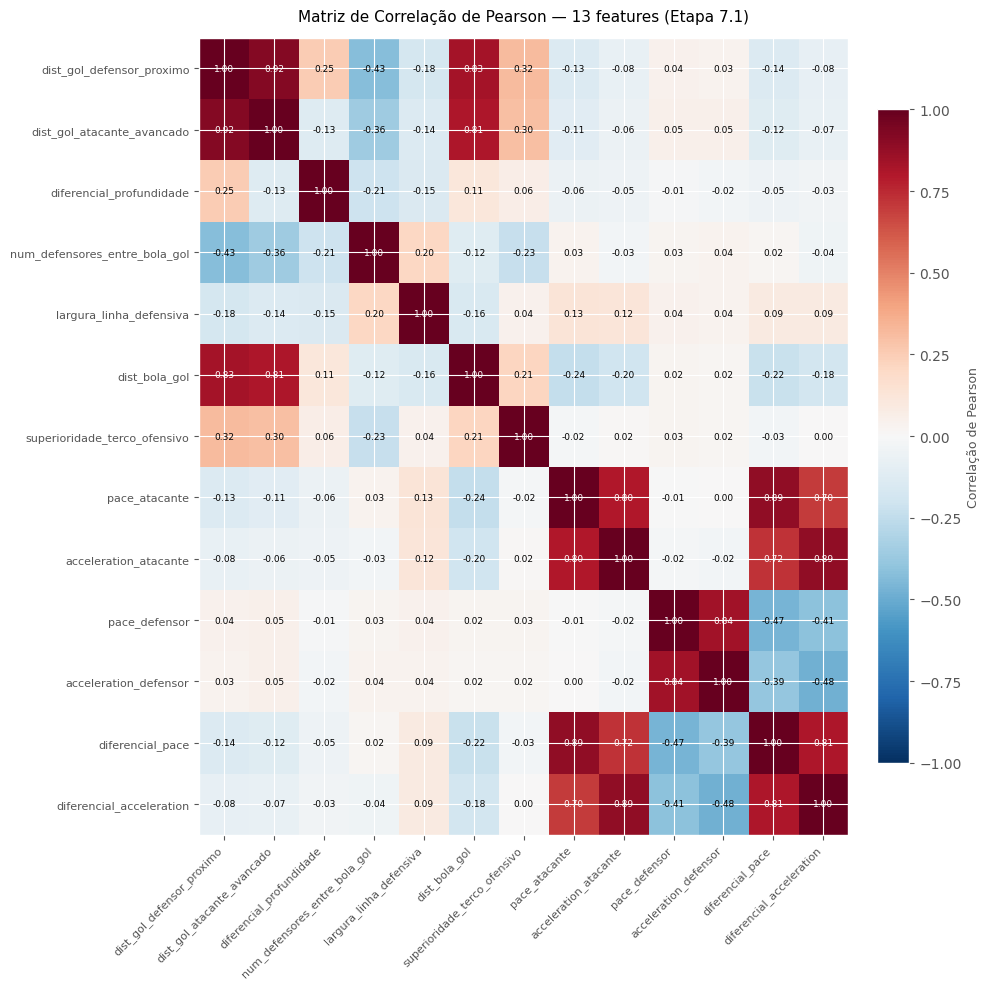


Top 5 correlações por |valor| (excluindo diagonal):
  Feature A                           Feature B                           Correlação
  ----------------------------------------------------------------------------------
  dist_gol_defensor_proximo           dist_gol_atacante_avancado             +0.9152
  pace_atacante                       diferencial_pace                       +0.8874
  acceleration_atacante               diferencial_acceleration               +0.8870
  pace_defensor                       acceleration_defensor                  +0.8434
  dist_gol_defensor_proximo           dist_bola_gol                          +0.8335


In [150]:
# =======================================================
# ANÁLISE 7.1 — Matriz de correlação entre as 13 features
# =======================================================
import itertools

features_todas = FEATURES_ESPACIAIS + FEATURES_FISICAS

df_corr_raw = df_dataset_completo[features_todas].dropna()
print(f"Amostras usadas para correlação: {len(df_corr_raw)}")

corr = df_corr_raw.corr()

# --- Heatmap com matplotlib puro (seaborn não disponível neste ambiente) ---
fig, ax = plt.subplots(figsize=(10, 10))
cmap = plt.cm.RdBu_r
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlação de Pearson', fontsize=9)

n = len(features_todas)
for i in range(n):
    for j in range(n):
        val = corr.values[i, j]
        cor_txt = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=cor_txt)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(features_todas, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(features_todas, fontsize=8)
ax.set_title('Matriz de Correlação de Pearson — 13 features (Etapa 7.1)', fontsize=11, pad=12)
plt.tight_layout()
plt.show()

# --- Top 5 pares por valor absoluto (excluindo diagonal) ---
pares = [
    (features_todas[i], features_todas[j], corr.values[i, j])
    for i, j in itertools.combinations(range(n), 2)
]
pares_ord = sorted(pares, key=lambda x: abs(x[2]), reverse=True)

print(f"\nTop 5 correlações por |valor| (excluindo diagonal):")
print(f"  {'Feature A':<35} {'Feature B':<35} {'Correlação':>10}")
print("  " + "-" * 82)
for fa, fb, c in pares_ord[:5]:
    print(f"  {fa:<35} {fb:<35} {c:>+10.4f}")

### 7.2 — Modelo C: Espacial + Diferencial de Pace

Motivado pelo diagnóstico de multicolinearidade da Seção 7.1, o Modelo C reduz o bloco físico a uma única feature — `diferencial_pace` — que:

- É a feature física de maior magnitude absoluta no Modelo B (`+0.1879`).
- Tem interpretação direta: vantagem de velocidade máxima do atacante sobre a média dos defensores.
- Elimina a redundância com `diferencial_acceleration` e os atributos brutos de pace/aceleração.

O protocolo é idêntico aos Modelos A e B: split 80/20 estratificado (`random_state=42`), `StandardScaler`, `LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)`.

In [151]:
# =======================================================
# ANÁLISE 7.2 — Modelo C: Espacial + diferencial_pace
# =======================================================
FEATURES_C = FEATURES_ESPACIAIS + ['diferencial_pace']
print(f"Modelo C — {len(FEATURES_C)} features: {FEATURES_C}\n")

cols_C = FEATURES_C + [ALVO]
df_C   = df_dataset_completo[cols_C].dropna()
print(f"Modelo C — linhas após remover NaN: {len(df_C)} (de {len(df_dataset_completo)})")

X_C = df_C[FEATURES_C].values
y_C = df_C[ALVO].astype(int).values

X_trC, X_teC, y_trC, y_teC = train_test_split(
    X_C, y_C, test_size=0.2, random_state=42, stratify=y_C
)

scaler_C = StandardScaler()
X_trC_s  = scaler_C.fit_transform(X_trC)
X_teC_s  = scaler_C.transform(X_teC)

lr_C = LogisticRegression(class_weight='balanced', max_iter=1000,
                           solver='lbfgs', random_state=42)
lr_C.fit(X_trC_s, y_trC)

y_prob_C  = lr_C.predict_proba(X_teC_s)[:, 1]
y_pred_C  = lr_C.predict(X_teC_s)
auc_C     = roc_auc_score(y_teC, y_prob_C)
auc_pr_C  = calcular_auc_pr(y_teC, y_prob_C)
brier_C   = brier_score_loss(y_teC, y_prob_C)
logloss_C = log_loss(y_teC, y_prob_C)
cm_C      = confusion_matrix(y_teC, y_pred_C)

print(f"\n{'='*52}")
print("MODELO C — Espacial + Diferencial de Pace")
print(f"{'='*52}")
print(f"AUC-ROC  : {auc_C:.4f}")
print(f"AUC-PR   : {auc_pr_C:.4f}")
print(f"Brier    : {brier_C:.4f}")
print(f"Log-loss : {logloss_C:.4f}")
print(f"\nMatriz de confusão (threshold 0.5):")
print(f"  TN={cm_C[0,0]:4d}  FP={cm_C[0,1]:4d}")
print(f"  FN={cm_C[1,0]:4d}  TP={cm_C[1,1]:4d}")
print(f"\nCoeficientes (ordem por magnitude absoluta):")
coefs_C = sorted(zip(FEATURES_C, lr_C.coef_[0]), key=lambda x: abs(x[1]), reverse=True)
for feat, coef in coefs_C:
    print(f"  {feat:<45} {coef:+.4f}")

# --- Tabela comparativa A vs B vs C ---
W = 92
print(f"\n{'='*W}")
print(f"{'Modelo':<30} {'AUC-ROC':>8} {'AUC-PR':>8} {'Brier':>8} {'Log-loss':>10} {'N feat.':>10}")
print(f"{'-'*W}")
print(f"{'Baseline Espacial (A)':<30} {auc_A:>8.4f} {auc_pr_A:>8.4f} {brier_A:>8.4f} {logloss_A:>10.4f} {len(FEATURES_ESPACIAIS):>10d}")
print(f"{'Espacial + Físico (B)':<30} {auc_B:>8.4f} {auc_pr_B:>8.4f} {brier_B:>8.4f} {logloss_B:>10.4f} {len(FEATURES_ESPACIAIS + FEATURES_FISICAS):>10d}")
print(f"{'Espacial + Diff. Pace (C)':<30} {auc_C:>8.4f} {auc_pr_C:>8.4f} {brier_C:>8.4f} {logloss_C:>10.4f} {len(FEATURES_C):>10d}")
print(f"{'-'*W}")
print(f"{'Delta (B - A)':<30} {auc_B-auc_A:>+8.4f} {auc_pr_B-auc_pr_A:>+8.4f} {brier_B-brier_A:>+8.4f} {logloss_B-logloss_A:>+10.4f} {'':>10}")
print(f"{'Delta (C - A)':<30} {auc_C-auc_A:>+8.4f} {auc_pr_C-auc_pr_A:>+8.4f} {brier_C-brier_A:>+8.4f} {logloss_C-logloss_A:>+10.4f} {'':>10}")
print(f"{'='*W}")
print(f"Prevalência da classe positiva (baseline AUC-PR aleatório): {prev_alg:.4f}")

Modelo C — 8 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo', 'diferencial_pace']

Modelo C — linhas após remover NaN: 1602 (de 1689)

MODELO C — Espacial + Diferencial de Pace
AUC-ROC  : 0.7760
AUC-PR   : 0.1457
Brier    : 0.1890
Log-loss : 0.5532

Matriz de confusão (threshold 0.5):
  TN= 218  FP=  92
  FN=   3  TP=   8

Coeficientes (ordem por magnitude absoluta):
  dist_bola_gol                                 -1.5914
  dist_gol_defensor_proximo                     +0.8583
  dist_gol_atacante_avancado                    -0.3480
  largura_linha_defensiva                       +0.1860
  num_defensores_entre_bola_gol                 -0.1562
  superioridade_terco_ofensivo                  -0.1345
  diferencial_pace                              -0.0096
  diferencial_profundidade                      -0.0016

Modelo                 

### 7.3 — Validação Cruzada 5-Fold dos Três Modelos

Com apenas 25 exemplos positivos em ~1900 amostras, um split único 80/20 produz estimativas de AUC com alta variância — o conjunto de teste tem no máximo 5 positivos. A validação cruzada estratificada 5-fold distribui esses positivos pelos folds e permite quantificar a instabilidade.

**Critério de estabilidade adotado:** `|AUC split único − média CV| ≤ 1 desvio padrão`.

In [152]:
# =======================================================
# ANÁLISE 7.3 — Cross-validation 5-fold dos três modelos
# =======================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = [
    ('A — Baseline Espacial',     FEATURES_ESPACIAIS,                     auc_A,  auc_pr_A),
    ('B — Espacial + Físico',     FEATURES_ESPACIAIS + FEATURES_FISICAS,  auc_B,  auc_pr_B),
    ('C — Espacial + Diff. Pace', FEATURES_C,                             auc_C,  auc_pr_C),
]

resultados_cv = []

for nome, features, auc_split, auc_pr_split in modelos_cv:
    df_cv = df_dataset_completo[features + [ALVO]].dropna()
    X_cv  = df_cv[features].values
    y_cv  = df_cv[ALVO].astype(int).values

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000,
                                   solver='lbfgs', random_state=42))
    ])
    scores    = cross_val_score(pipe, X_cv, y_cv, scoring='roc_auc',           cv=cv)
    scores_pr = cross_val_score(pipe, X_cv, y_cv, scoring='average_precision', cv=cv)

    media    = scores.mean()
    std      = scores.std()
    media_pr = scores_pr.mean()
    std_pr   = scores_pr.std()
    # Estável: |AUC split único − média CV| ≤ 1 desvio padrão
    estavel = 'Sim' if abs(auc_split - media) <= std else 'Não'

    print(f"Modelo {nome}")
    print(f"  ROC — Scores por fold: {[f'{s:.4f}' for s in scores]}")
    print(f"        Média: {media:.4f}  |  Desvio: {std:.4f}  |  Estável: {estavel}")
    print(f"  PR  — Scores por fold: {[f'{s:.4f}' for s in scores_pr]}")
    print(f"        Média: {media_pr:.4f}  |  Desvio: {std_pr:.4f}\n")

    resultados_cv.append({
        'nome': nome,
        'auc_split':      auc_split,    'auc_cv_media':    media,    'auc_cv_std':    std,
        'auc_pr_split':   auc_pr_split, 'auc_pr_cv_media': media_pr, 'auc_pr_cv_std': std_pr,
        'estavel': estavel,
    })

# Tabela final
W2 = 105
print(f"\n{'='*W2}")
print(f"{'Modelo':<30} {'AUC-ROC (split)':>15} {'AUC-ROC (CV)':>22} {'AUC-PR (split)':>15} {'AUC-PR (CV)':>20}")
print(f"{'-'*W2}")
for r in resultados_cv:
    cv_roc = f"{r['auc_cv_media']:.4f} ± {r['auc_cv_std']:.4f}"
    cv_pr  = f"{r['auc_pr_cv_media']:.4f} ± {r['auc_pr_cv_std']:.4f}"
    print(f"{r['nome']:<30} {r['auc_split']:>15.4f} {cv_roc:>22} {r['auc_pr_split']:>15.4f} {cv_pr:>20}")
print(f"{'='*W2}")
print(f"\nCritério de estabilidade: |AUC split único − média CV| ≤ 1 desvio padrão.")
print(f"Prevalência da classe positiva (baseline AUC-PR aleatório): {prev_alg:.4f}")

Modelo A — Baseline Espacial
  ROC — Scores por fold: ['0.8649', '0.6633', '0.7870', '0.7779', '0.6813']
        Média: 0.7549  |  Desvio: 0.0741  |  Estável: Sim
  PR  — Scores por fold: ['0.2672', '0.0584', '0.1038', '0.1496', '0.0692']
        Média: 0.1296  |  Desvio: 0.0758

Modelo B — Espacial + Físico
  ROC — Scores por fold: ['0.8323', '0.6408', '0.8255', '0.6526', '0.7902']
        Média: 0.7483  |  Desvio: 0.0843  |  Estável: Sim
  PR  — Scores por fold: ['0.1442', '0.0592', '0.2290', '0.0650', '0.0820']
        Média: 0.1159  |  Desvio: 0.0641

Modelo C — Espacial + Diff. Pace
  ROC — Scores por fold: ['0.8246', '0.6801', '0.8229', '0.6826', '0.7811']
        Média: 0.7583  |  Desvio: 0.0647  |  Estável: Sim
  PR  — Scores por fold: ['0.1528', '0.0728', '0.1535', '0.0762', '0.0763']
        Média: 0.1063  |  Desvio: 0.0383


Modelo                         AUC-ROC (split)           AUC-ROC (CV)  AUC-PR (split)          AUC-PR (CV)
---------------------------------------------

## Etapa 7.5 — Tuning de Hiperparâmetros via Optuna

Até aqui, os modelos XGBoost usariam hiperparâmetros escolhidos manualmente por bom senso. Para a **defesa metodológica formal** do trabalho, esta etapa substitui essa escolha por hiperparâmetros selecionados via **Optuna** (busca bayesiana com *Tree-structured Parzen Estimator*, TPE), executada **antes** do treinamento dos modelos das Etapas 8 e 9.

**Por que tunar uma única vez sobre o A_xgb?** A comparação central A vs B exige **hiperparâmetros idênticos** entre os dois modelos — qualquer diferença observada deve refletir apenas o conjunto de features, não o tuning. Por isso o Optuna otimiza uma só vez, sobre o **Modelo A_xgb** (dataset algorítmico, 7 features espaciais), e os hiperparâmetros ótimos (`PARAMS_XGB_TUNED`) são propagados de forma idêntica aos **quatro** modelos XGBoost (A_xgb, B_xgb, A_xgb_sb, B_xgb_sb).

**Por que ranges conservadores?** Com poucos exemplos positivos, espaços de busca largos demais levam a sobreajuste ao próprio CV. Os intervalos são propositalmente estreitos (profundidade rasa, regularização presente) para favorecer generalização.

A função objetivo retorna o **AUC-ROC médio sob CV 5-fold** (mesmo `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` das Etapas 7.3 e 8.4, garantindo comparabilidade direta com os modelos logísticos). Os hiperparâmetros resultantes passam a ser a **única** fonte de configuração dos XGBoosts — o `PARAMS_XGB` manual é eliminado.

In [153]:
# =======================================================
# ETAPA 7.5 — Tuning de hiperparâmetros via Optuna
# =======================================================
# Otimiza UMA vez sobre o Modelo A_xgb (7 features espaciais, dataset
# algorítmico). Os hiperparâmetros ótimos viram PARAMS_XGB_TUNED e são
# aplicados de forma idêntica aos quatro modelos XGBoost (Etapas 8 e 9).

try:
    import optuna
    from optuna.samplers import TPESampler
except ImportError:
    print("optuna não instalado. Peça permissão antes de rodar "
          "pip install optuna --break-system-packages.")
    raise

from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Dataset de tuning: idêntico ao A_xgb (Etapa 8.2) ---
df_A_full = df_dataset_completo[FEATURES_ESPACIAIS + [ALVO]].dropna()
X_A_full  = df_A_full[FEATURES_ESPACIAIS]
y_A_full  = df_A_full[ALVO].astype(int)
print(f"Tuning sobre A_xgb — {len(FEATURES_ESPACIAIS)} features, "
      f"{len(df_A_full)} linhas, {int(y_A_full.sum())} positivos.\n")


def objetivo_optuna(trial):
    """
    Função objetivo: retorna AUC-ROC médio sob CV 5-fold para um conjunto
    de hiperparâmetros. Treina apenas o Modelo A_xgb (7 features espaciais,
    dataset algorítmico).
    """
    params = {
        'objective':         'binary:logistic',
        'eval_metric':       'auc',
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 5),
        'n_estimators':      trial.suggest_int('n_estimators', 50, 200, step=25),
        'min_child_weight':  trial.suggest_int('min_child_weight', 3, 10),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':      42,
        'n_jobs':            -1,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_A_full, y_A_full):
        X_tr, X_val = X_A_full.iloc[train_idx], X_A_full.iloc[val_idx]
        y_tr, y_val = y_A_full.iloc[train_idx], y_A_full.iloc[val_idx]

        scaler_fold = StandardScaler()
        X_tr_s = scaler_fold.fit_transform(X_tr)
        X_val_s = scaler_fold.transform(X_val)

        n_pos = (y_tr == 1).sum()
        n_neg = (y_tr == 0).sum()
        spw = n_neg / n_pos if n_pos > 0 else 1.0

        model = XGBClassifier(**params, scale_pos_weight=spw)
        model.fit(X_tr_s, y_tr)
        proba = model.predict_proba(X_val_s)[:, 1]
        scores.append(roc_auc_score(y_val, proba))

    return np.mean(scores)


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
)
study.optimize(objetivo_optuna, n_trials=30, show_progress_bar=True)

print("Melhor AUC-ROC (CV 5-fold):", round(study.best_value, 4))
print("Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"  {k:20s} = {v}")

# --- Hiperparâmetros tunados: única fonte de configuração dos XGBoosts ---
PARAMS_XGB_TUNED = {
    **study.best_params,
    'eval_metric':  'logloss',
    'random_state': 42,
    'n_jobs':       -1,
}

Tuning sobre A_xgb — 7 features, 1689 linhas, 56 positivos.



Best trial: 21. Best value: 0.76265: 100%|██████████| 30/30 [00:07<00:00,  3.98it/s]

Melhor AUC-ROC (CV 5-fold): 0.7626
Melhores hiperparâmetros:
  learning_rate        = 0.01769018160102042
  max_depth            = 4
  n_estimators         = 50
  min_child_weight     = 9
  subsample            = 0.6297490068095127
  colsample_bytree     = 0.9902073287271537
  reg_alpha            = 1.6093544222356557
  reg_lambda           = 0.00912670412409843


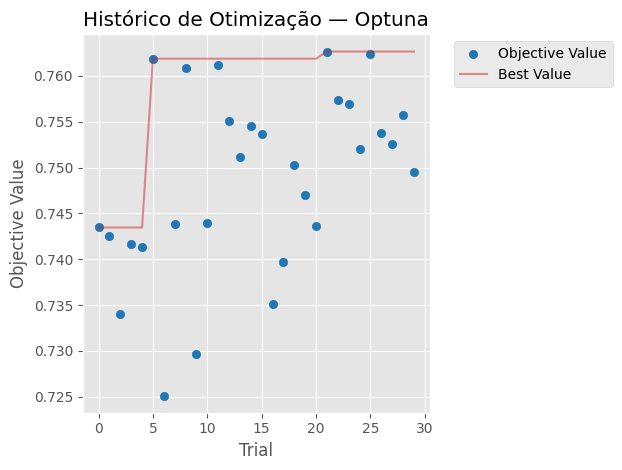

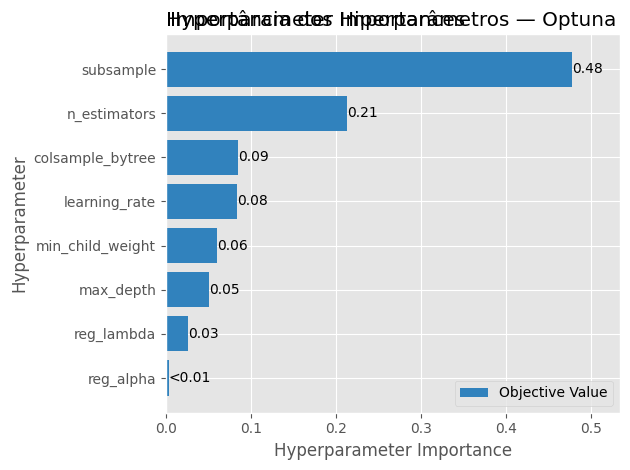

In [154]:
# =======================================================
# ETAPA 7.5 — Visualizações do estudo Optuna
# =======================================================
import optuna.visualization.matplotlib as ov

ov.plot_optimization_history(study)
plt.title("Histórico de Otimização — Optuna")
plt.tight_layout()
plt.show()

ov.plot_param_importances(study)
plt.title("Importância dos Hiperparâmetros — Optuna")
plt.tight_layout()
plt.show()

## Etapa 8 — XGBoost: A_xgb vs B_xgb

Para responder se o **prior físico do FM2023 impacta a capacidade preditiva** do modelo de contra-ataques, esta etapa replica a comparação central das regressões logísticas num modelo não-linear. Dois XGBoosts são treinados com **hiperparâmetros idênticos**, diferindo apenas no conjunto de features:

- **A_xgb**: 7 features espaciais (mesmo conjunto do Modelo A logístico).
- **B_xgb**: 13 features — espaciais + físicas (mesmo conjunto do Modelo B logístico).

Os hiperparâmetros (`PARAMS_XGB_TUNED`) foram **selecionados via Optuna na Etapa 7.5** e são aplicados de forma idêntica aos dois modelos — garantindo que o delta reflita apenas as features.

O delta **Δ AUC (B_xgb − A_xgb)** é então comparado ao **Δ AUC (B − A)** das logísticas. Se o prior físico não agrega na logística mas agrega no XGBoost, isso sugere interações não-lineares envolvendo features físicas que a logística não capturava.

In [155]:
# =======================================================
# ETAPA 8.1 — Import e verificação do XGBoost
# =======================================================
try:
    from xgboost import XGBClassifier
    print("XGBoost disponível.")
except ImportError:
    raise RuntimeError(
        "XGBoost não instalado. Execute: pip install xgboost"
    )

XGBoost disponível.


In [156]:
# =======================================================
# ETAPA 8.2 — Preparação: A_xgb (espacial) e B_xgb (espacial + físico)
# =======================================================

# Hiperparâmetros idênticos para os dois modelos:
# selecionados via Optuna na Etapa 7.5 (PARAMS_XGB_TUNED), não mais manuais.

# --- Modelo A_xgb: 7 features espaciais ---
cols_Axgb = FEATURES_ESPACIAIS + [ALVO]
df_Axgb   = df_dataset_completo[cols_Axgb].dropna()
print(f"A_xgb — {len(FEATURES_ESPACIAIS)} features: {FEATURES_ESPACIAIS}")
print(f"A_xgb — linhas após remover NaN: {len(df_Axgb)} (de {len(df_dataset_completo)})\n")

X_Axgb = df_Axgb[FEATURES_ESPACIAIS].values
y_Axgb = df_Axgb[ALVO].values

X_trAxgb, X_teAxgb, y_trAxgb, y_teAxgb = train_test_split(
    X_Axgb, y_Axgb, test_size=0.2, stratify=y_Axgb, random_state=42
)
scaler_Axgb = StandardScaler()
X_trAxgb_s  = scaler_Axgb.fit_transform(X_trAxgb)
X_teAxgb_s  = scaler_Axgb.transform(X_teAxgb)
n_neg_Axgb  = (y_trAxgb == 0).sum()
n_pos_Axgb  = (y_trAxgb == 1).sum()
spw_Axgb    = n_neg_Axgb / n_pos_Axgb
print(f"A_xgb — Treino: {n_neg_Axgb} negativos, {n_pos_Axgb} positivos → scale_pos_weight = {spw_Axgb:.2f}")

xgb_Axgb = XGBClassifier(scale_pos_weight=spw_Axgb, **PARAMS_XGB_TUNED)

# --- Modelo B_xgb: 13 features (espaciais + físicas) ---
FEATURES_B_XGB = FEATURES_ESPACIAIS + FEATURES_FISICAS
cols_Bxgb = FEATURES_B_XGB + [ALVO]
df_Bxgb   = df_dataset_completo[cols_Bxgb].dropna()
print(f"\nB_xgb — {len(FEATURES_B_XGB)} features: {FEATURES_B_XGB}")
print(f"B_xgb — linhas após remover NaN: {len(df_Bxgb)} (de {len(df_dataset_completo)})\n")

X_Bxgb = df_Bxgb[FEATURES_B_XGB].values
y_Bxgb = df_Bxgb[ALVO].values

X_trBxgb, X_teBxgb, y_trBxgb, y_teBxgb = train_test_split(
    X_Bxgb, y_Bxgb, test_size=0.2, stratify=y_Bxgb, random_state=42
)
scaler_Bxgb = StandardScaler()
X_trBxgb_s  = scaler_Bxgb.fit_transform(X_trBxgb)
X_teBxgb_s  = scaler_Bxgb.transform(X_teBxgb)
n_neg_Bxgb  = (y_trBxgb == 0).sum()
n_pos_Bxgb  = (y_trBxgb == 1).sum()
spw_Bxgb    = n_neg_Bxgb / n_pos_Bxgb
print(f"B_xgb — Treino: {n_neg_Bxgb} negativos, {n_pos_Bxgb} positivos → scale_pos_weight = {spw_Bxgb:.2f}")

xgb_Bxgb = XGBClassifier(scale_pos_weight=spw_Bxgb, **PARAMS_XGB_TUNED)

A_xgb — 7 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo']
A_xgb — linhas após remover NaN: 1689 (de 1689)

A_xgb — Treino: 1306 negativos, 45 positivos → scale_pos_weight = 29.02

B_xgb — 13 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo', 'pace_atacante', 'acceleration_atacante', 'pace_defensor', 'acceleration_defensor', 'diferencial_pace', 'diferencial_acceleration']
B_xgb — linhas após remover NaN: 1602 (de 1689)

B_xgb — Treino: 1239 negativos, 42 positivos → scale_pos_weight = 29.50


In [157]:
# =======================================================
# ETAPA 8.3 — Treino e avaliação: A_xgb e B_xgb
# =======================================================

def _avaliar_xgb(nome, modelo, X_tr, y_tr, X_te, y_te, features):
    modelo.fit(X_tr, y_tr)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    y_pred = modelo.predict(X_te)
    auc    = roc_auc_score(y_te, y_prob)
    auc_pr = calcular_auc_pr(y_te, y_prob)
    brier  = brier_score_loss(y_te, y_prob)
    ll     = log_loss(y_te, y_prob)
    cm     = confusion_matrix(y_te, y_pred)

    print("=" * 52)
    print(f"MODELO {nome}")
    print("=" * 52)
    print(f"AUC-ROC  : {auc:.4f}")
    print(f"AUC-PR   : {auc_pr:.4f}")
    print(f"Brier    : {brier:.4f}")
    print(f"Log-loss : {ll:.4f}")
    print("Matriz de confusão (threshold 0.5):")
    print(f"  TN={cm[0, 0]:4d}  FP={cm[0, 1]:4d}")
    print(f"  FN={cm[1, 0]:4d}  TP={cm[1, 1]:4d}")
    print("\nFeature importance (ordenada):")
    imp = sorted(zip(features, modelo.feature_importances_),
                 key=lambda x: x[1], reverse=True)
    for feat, val in imp:
        print(f"  {feat:<45} {val * 100:5.1f}%")
    print()
    return auc, brier, ll, auc_pr


auc_Axgb, brier_Axgb, ll_Axgb, auc_pr_Axgb = _avaliar_xgb(
    "A_xgb — XGBoost Espacial",
    xgb_Axgb, X_trAxgb_s, y_trAxgb, X_teAxgb_s, y_teAxgb,
    FEATURES_ESPACIAIS,
)

auc_Bxgb, brier_Bxgb, ll_Bxgb, auc_pr_Bxgb = _avaliar_xgb(
    "B_xgb — XGBoost Espacial + Físico",
    xgb_Bxgb, X_trBxgb_s, y_trBxgb, X_teBxgb_s, y_teBxgb,
    FEATURES_B_XGB,
)

MODELO A_xgb — XGBoost Espacial
AUC-ROC  : 0.7815
AUC-PR   : 0.0840
Brier    : 0.1467
Log-loss : 0.4740
Matriz de confusão (threshold 0.5):
  TN= 290  FP=  37
  FN=   7  TP=   4

Feature importance (ordenada):
  dist_bola_gol                                  27.9%
  dist_gol_atacante_avancado                     19.7%
  num_defensores_entre_bola_gol                  13.4%
  diferencial_profundidade                       13.2%
  largura_linha_defensiva                        13.0%
  dist_gol_defensor_proximo                      11.2%
  superioridade_terco_ofensivo                    1.6%

MODELO B_xgb — XGBoost Espacial + Físico
AUC-ROC  : 0.7525
AUC-PR   : 0.1019
Brier    : 0.1399
Log-loss : 0.4547
Matriz de confusão (threshold 0.5):
  TN= 255  FP=  55
  FN=   6  TP=   5

Feature importance (ordenada):
  dist_bola_gol                                  17.5%
  dist_gol_atacante_avancado                     13.9%
  acceleration_atacante                           8.9%
  diferencial_accele

In [158]:
# =======================================================
# ETAPA 8.4 — Cross-validation 5-fold: A_xgb e B_xgb
# =======================================================
# Mesmo StratifiedKFold da Etapa 7.3 para comparabilidade direta

cv_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def _cv_xgb_model(nome, features_list, df_data, params, spw, auc_split):
    X_cv = df_data[features_list].values
    y_cv = df_data[ALVO].values
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb',   XGBClassifier(scale_pos_weight=spw, **params)),
    ])
    scores    = cross_val_score(pipe, X_cv, y_cv, cv=cv_xgb, scoring='roc_auc')
    scores_pr = cross_val_score(pipe, X_cv, y_cv, cv=cv_xgb, scoring='average_precision')
    media    = scores.mean()
    std      = scores.std()
    media_pr = scores_pr.mean()
    std_pr   = scores_pr.std()
    estavel  = 'Sim' if abs(auc_split - media) <= std else 'Não'
    print(f"{nome}")
    print(f"  ROC — Scores por fold : {[f'{s:.4f}' for s in scores]}")
    print(f"         Média          : {media:.4f}  |  Desvio: {std:.4f}  |  Estável: {estavel}")
    print(f"  PR  — Scores por fold : {[f'{s:.4f}' for s in scores_pr]}")
    print(f"         Média          : {media_pr:.4f}  |  Desvio: {std_pr:.4f}")
    return media, std, estavel, media_pr, std_pr


print("=== Cross-validation 5-fold ===\n")
media_Axgb, std_Axgb, estavel_Axgb, media_pr_Axgb, std_pr_Axgb = _cv_xgb_model(
    "A_xgb — XGBoost Espacial",
    FEATURES_ESPACIAIS, df_Axgb, PARAMS_XGB_TUNED, spw_Axgb, auc_Axgb,
)
print()
media_Bxgb, std_Bxgb, estavel_Bxgb, media_pr_Bxgb, std_pr_Bxgb = _cv_xgb_model(
    "B_xgb — XGBoost Espacial + Físico",
    FEATURES_B_XGB, df_Bxgb, PARAMS_XGB_TUNED, spw_Bxgb, auc_Bxgb,
)

=== Cross-validation 5-fold ===

A_xgb — XGBoost Espacial
  ROC — Scores por fold : ['0.8693', '0.6888', '0.7398', '0.7914', '0.7202']
         Média          : 0.7619  |  Desvio: 0.0632  |  Estável: Sim
  PR  — Scores por fold : ['0.1931', '0.0888', '0.0785', '0.1662', '0.0840']
         Média          : 0.1221  |  Desvio: 0.0479

B_xgb — XGBoost Espacial + Físico
  ROC — Scores por fold : ['0.7959', '0.6391', '0.7926', '0.5956', '0.7382']
         Média          : 0.7123  |  Desvio: 0.0813  |  Estável: Sim
  PR  — Scores por fold : ['0.1316', '0.0706', '0.1183', '0.0464', '0.0676']
         Média          : 0.0869  |  Desvio: 0.0324


In [159]:
# =======================================================
# ETAPA 8.5 — Tabela comparativa: A, B, C, A_xgb, B_xgb
# =======================================================
# Reutiliza resultados_cv da Etapa 7.3 e acrescenta os dois XGBoosts

resultados_cv_todos = resultados_cv + [
    {
        'nome':            'A_xgb — XGBoost Espacial',
        'auc_split':       auc_Axgb,      'auc_cv_media':    media_Axgb,    'auc_cv_std':    std_Axgb,
        'auc_pr_split':    auc_pr_Axgb,   'auc_pr_cv_media': media_pr_Axgb, 'auc_pr_cv_std': std_pr_Axgb,
        'estavel':         estavel_Axgb,
    },
    {
        'nome':            'B_xgb — XGBoost Esp. + Físico',
        'auc_split':       auc_Bxgb,      'auc_cv_media':    media_Bxgb,    'auc_cv_std':    std_Bxgb,
        'auc_pr_split':    auc_pr_Bxgb,   'auc_pr_cv_media': media_pr_Bxgb, 'auc_pr_cv_std': std_pr_Bxgb,
        'estavel':         estavel_Bxgb,
    },
]

W = 110
print("=" * W)
print(f"{'Modelo':<38} {'AUC-ROC (split)':>15}  {'AUC-ROC (CV)':>18}  {'AUC-PR (split)':>15}  {'AUC-PR (CV)':>16}")
print("-" * W)
for r in resultados_cv_todos:
    cv_roc = f"{r['auc_cv_media']:.4f} ± {r['auc_cv_std']:.4f}"
    cv_pr  = f"{r['auc_pr_cv_media']:.4f} ± {r['auc_pr_cv_std']:.4f}"
    print(f"{r['nome']:<38} {r['auc_split']:>15.4f}  {cv_roc:>18}  {r['auc_pr_split']:>15.4f}  {cv_pr:>16}")
print("=" * W)

# Deltas relativos ao baseline espacial (AUC CV)
auc_A_cv     = next(r['auc_cv_media']    for r in resultados_cv if r['nome'].startswith('A'))
auc_B_cv     = next(r['auc_cv_media']    for r in resultados_cv if r['nome'].startswith('B'))
auc_pr_A_cv  = next(r['auc_pr_cv_media'] for r in resultados_cv if r['nome'].startswith('A'))
auc_pr_B_cv  = next(r['auc_pr_cv_media'] for r in resultados_cv if r['nome'].startswith('B'))
delta_log    = auc_B_cv    - auc_A_cv
delta_xgb    = media_Bxgb  - media_Axgb
delta_pr_log = auc_pr_B_cv - auc_pr_A_cv
delta_pr_xgb = media_pr_Bxgb - media_pr_Axgb

print(f"\nDeltas relativos ao baseline espacial (AUC CV):")
print(f"  Δ AUC-ROC (B     − A)      = {delta_log:+.4f}  (logística)")
print(f"  Δ AUC-ROC (B_xgb − A_xgb) = {delta_xgb:+.4f}  (XGBoost)")
print(f"  Δ AUC-PR  (B     − A)      = {delta_pr_log:+.4f}  (logística)")
print(f"  Δ AUC-PR  (B_xgb − A_xgb) = {delta_pr_xgb:+.4f}  (XGBoost)")
print(f"\nPrevalência da classe positiva (baseline AUC-PR aleatório): {prev_alg:.4f}")

# Aliases de compatibilidade com a Etapa 9 (usa variáveis do antigo Modelo D)
auc_D   = auc_Bxgb
media_D = media_Bxgb
std_D   = std_Bxgb

Modelo                                 AUC-ROC (split)        AUC-ROC (CV)   AUC-PR (split)       AUC-PR (CV)
--------------------------------------------------------------------------------------------------------------
A — Baseline Espacial                           0.7882     0.7549 ± 0.0741           0.0799   0.1296 ± 0.0758
B — Espacial + Físico                           0.7771     0.7483 ± 0.0843           0.1241   0.1159 ± 0.0641
C — Espacial + Diff. Pace                       0.7760     0.7583 ± 0.0647           0.1457   0.1063 ± 0.0383
A_xgb — XGBoost Espacial                        0.7815     0.7619 ± 0.0632           0.0840   0.1221 ± 0.0479
B_xgb — XGBoost Esp. + Físico                   0.7525     0.7123 ± 0.0813           0.1019   0.0869 ± 0.0324

Deltas relativos ao baseline espacial (AUC CV):
  Δ AUC-ROC (B     − A)      = -0.0066  (logística)
  Δ AUC-ROC (B_xgb − A_xgb) = -0.0496  (XGBoost)
  Δ AUC-PR  (B     − A)      = -0.0138  (logística)
  Δ AUC-PR  (B_xgb − A_xgb)

## Etapa 9 — Análise Paralela: Definição StatsBomb (From Counter) com XGBoost

As Etapas 1–8 utilizam uma **definição algorítmica** de contra-ataque (Ball Recovery na zona defensiva + progressão + janela de tempo). Esta etapa constrói uma **análise paralela e independente** baseada na definição anotada humana da StatsBomb: eventos com `play_pattern_name == 'From Counter'`. O `play_pattern_name` é atribuído a cada posse e propagado para todos os eventos da mesma posse — logo, todos os eventos de uma mesma sequência ofensiva 'From Counter' compartilham o mesmo valor.

**Nada das células 0–42 é modificado.** Dataset próprio, modelo próprio, comparação lado a lado.

In [160]:
# =======================================================
# ETAPA 9.1 — Função identificar_contra_ataques_sb
# =======================================================
# Identifica cadeias rotuladas como 'From Counter' pela StatsBomb.
# Não aplica filtros de zona, max_eventos, tempo ou progressão — a
# segmentação já foi feita pela equipe de anotação humana.
# Retorna lista de dicts com a mesma estrutura de identificar_contra_ataques.

def identificar_contra_ataques_sb(df_event, cfg):
    criterio_sucesso = cfg["criterio_sucesso"]
    xg_thr = cfg.get("xg_threshold", 0.0)

    df_ev = df_event.sort_values(
        ["period", "minute", "second", "index"]
    ).reset_index(drop=True)

    contra_ataques = []
    cadeia = []
    equipe_atual = None

    for _, ev in df_ev.iterrows():
        eh_counter = ev["play_pattern_name"] == "From Counter"
        mesma_equipe = ev["team_name"] == equipe_atual

        if eh_counter and (not cadeia or mesma_equipe):
            # Continua ou inicia cadeia
            if not cadeia:
                equipe_atual = ev["team_name"]
            cadeia.append(ev)
        else:
            # Encerra cadeia anterior (se havia)
            if cadeia:
                _registrar_cadeia_sb(
                    cadeia, criterio_sucesso, xg_thr, contra_ataques
                )
                cadeia = []
                equipe_atual = None
            # Inicia nova cadeia se este evento é From Counter
            if eh_counter:
                equipe_atual = ev["team_name"]
                cadeia.append(ev)

    # Última cadeia (caso o jogo termine em From Counter)
    if cadeia:
        _registrar_cadeia_sb(
            cadeia, criterio_sucesso, xg_thr, contra_ataques
        )

    return contra_ataques


def _registrar_cadeia_sb(cadeia, criterio_sucesso, xg_thr, contra_ataques):
    primeiro = cadeia[0]
    ultimo   = cadeia[-1]

    x_ini = float(primeiro.get("x") or 0.0)
    x_fim = ultimo.get("end_x")
    if pd.isna(x_fim):
        x_fim = ultimo.get("x", x_ini)
    x_fim = float(x_fim) if not pd.isna(x_fim) else x_ini

    t0      = primeiro["minute"] * 60 + primeiro["second"]
    t_fim   = ultimo["minute"]   * 60 + ultimo["second"]
    duracao = float(t_fim - t0)

    terminou_chute = (ultimo["type_name"] == "Shot")
    xg_final = (
        float(ultimo.get("shot_statsbomb_xg") or 0)
        if terminou_chute else 0.0
    )

    if criterio_sucesso == "qualquer_chute":
        sucesso = terminou_chute
    elif criterio_sucesso == "gol":
        sucesso = terminou_chute and str(
            ultimo.get("outcome_name", "")
        ).lower() == "goal"
    else:  # xg_threshold
        sucesso = bool(terminou_chute and xg_final >= xg_thr)

    contra_ataques.append({
        "id_inicio":      primeiro["id"],
        "player_id":      primeiro.get("player_id"),
        "player_name":    str(primeiro.get("player_name", "")),
        "team":           primeiro["team_name"],
        "period":         int(primeiro["period"]),
        "minute":         int(primeiro["minute"]),
        "second":         int(primeiro["second"]),
        "tipo_inicio":    primeiro["type_name"],
        "x_inicio":       x_ini,
        "y_inicio":       float(primeiro.get("y") or 40.0),
        "num_eventos":    len(cadeia),
        "progressao_x":   float(x_fim - x_ini),
        "duracao_s":      duracao,
        "terminou_chute": terminou_chute,
        "xg_final":       xg_final,
        "sucesso":        bool(sucesso),
        "play_pattern":   "From Counter",
    })


print("Funções identificar_contra_ataques_sb e _registrar_cadeia_sb definidas.")

Funções identificar_contra_ataques_sb e _registrar_cadeia_sb definidas.


In [161]:
# =======================================================
# ETAPA 9.2 — Função processar_partida_sb
# =======================================================
# Espelha processar_partida (Etapa 5A), substituindo apenas
# identificar_contra_ataques por identificar_contra_ataques_sb.
# Reutiliza extrair_features_espaciais, buscar_fm e
# get_defender_attrs_medios sem modificação.

def processar_partida_sb(match_id, config):
    # 1. Carregamento
    df_ev, _, _, df_tac = parser.event(match_id)
    df_fr, _            = parser.frame(match_id)
    df_ln               = parser.lineup(match_id)

    # Mapeamento player_id → nacionalidade FM
    nat_map = (
        df_ln
        .assign(nat_fm=df_ln["country_name"].map(COUNTRY_TO_FM))
        .set_index("player_id")["nat_fm"]
        .to_dict()
    )

    # 2. Identificação pela definição StatsBomb
    cas = identificar_contra_ataques_sb(df_ev, config)
    if not cas:
        return pd.DataFrame(), 0, 0

    n_ca_total = len(cas)

    # 3. Features espaciais (freeze frame 360)
    feat_rows, n_sem_frame = [], 0
    for ca in cas:
        feats = extrair_features_espaciais(ca["id_inicio"], df_ev, df_fr)
        if feats is not None:
            feat_rows.append(feats)
        else:
            n_sem_frame += 1

    if not feat_rows:
        return pd.DataFrame(), n_ca_total, n_sem_frame

    df_feats   = pd.DataFrame(feat_rows)
    df_dataset = (
        pd.DataFrame(cas)
        .merge(df_feats.rename(columns={"event_id": "id_inicio"}),
               on="id_inicio", how="inner")
    )

    # 4. Atributos físicos FM2023
    defender_attrs = get_defender_attrs_medios(df_ev, df_tac)
    equipes_lista  = list(defender_attrs.keys())

    fm_rows = []
    for _, ca in df_dataset.iterrows():
        equipe_atac = ca["team"]
        equipe_def  = next(
            (e for e in equipes_lista if e != equipe_atac), equipe_atac
        )

        atac_name = ca.get("player_name", "")
        atac_pid  = ca.get("player_id")
        nat_raw   = nat_map.get(atac_pid) if pd.notna(atac_pid or np.nan) else None
        atac_nat  = nat_raw if isinstance(nat_raw, str) else None

        atac_attrs, _, _ = buscar_fm(atac_name, nationality=atac_nat)
        if atac_attrs is None:
            atac_attrs = {a: np.nan for a in FM_ATTRS}

        def_info = defender_attrs.get(equipe_def, {})
        pac_atac = atac_attrs.get("Pac", np.nan)
        acc_atac = atac_attrs.get("Acc", np.nan)
        pac_def  = def_info.get("Pac", np.nan)
        acc_def  = def_info.get("Acc", np.nan)

        fm_rows.append({
            "id_inicio":              ca["id_inicio"],
            "pace_atacante":          pac_atac,
            "acceleration_atacante":  acc_atac,
            "stamina_atacante":       atac_attrs.get("Sta", np.nan),
            "pace_defensor":          pac_def,
            "acceleration_defensor":  acc_def,
            "diferencial_pace":       (
                (pac_atac - pac_def)
                if not (pd.isna(pac_atac) or pd.isna(pac_def)) else np.nan
            ),
            "diferencial_acceleration": (
                (acc_atac - acc_def)
                if not (pd.isna(acc_atac) or pd.isna(acc_def)) else np.nan
            ),
        })

    df_fm_feats = pd.DataFrame(fm_rows)
    df_result   = df_dataset.merge(df_fm_feats, on="id_inicio", how="left")
    df_result["match_id"] = match_id
    return df_result, n_ca_total, n_sem_frame


print("Função processar_partida_sb definida.")

Função processar_partida_sb definida.


In [162]:
# =======================================================
# ETAPA 9.3 — Loop sobre 64 partidas (definição StatsBomb)
# =======================================================
PARQUET_PATH_SB = "dataset_sb_counters.parquet"

df_match_all_sb = parser.match(competition_id=COMPETITION_ID, season_id=SEASON_ID)
match_ids_sb    = df_match_all_sb["match_id"].tolist()

todos_dfs_sb  = []
auditoria_sb  = []
falhas_sb     = []

print(f"Processando {len(match_ids_sb)} partidas (definição StatsBomb)...\n")

for i, mid in enumerate(match_ids_sb, 1):
    row = df_match_all_sb[df_match_all_sb["match_id"] == mid].iloc[0]
    label = f"{row.get('home_team_name','?')} x {row.get('away_team_name','?')}"
    print(f"[{i:2d}/{len(match_ids_sb)}] {label} (id={mid}) ...", end=" ", flush=True)

    try:
        df_p, n_ca, n_sf = processar_partida_sb(mid, config)
        n_rows = len(df_p)
        if n_rows > 0:
            todos_dfs_sb.append(df_p)
        auditoria_sb.append({
            "match_id":    mid,
            "partida":     label,
            "n_ca_total":  n_ca,
            "n_sem_frame": n_sf,
            "n_no_dataset": n_rows,
            "erro":        None,
        })
        print(f"OK — {n_ca} CAs, {n_sf} sem frame, {n_rows} no dataset")
    except Exception as exc:
        falhas_sb.append((mid, label, str(exc)))
        auditoria_sb.append({
            "match_id":    mid,
            "partida":     label,
            "n_ca_total":  None,
            "n_sem_frame": None,
            "n_no_dataset": 0,
            "erro":        str(exc),
        })
        print(f"ERRO: {exc}")

df_dataset_sb_counters = (
    pd.concat(todos_dfs_sb, ignore_index=True)
    if todos_dfs_sb else pd.DataFrame()
)

if len(df_dataset_sb_counters) > 0:
    df_dataset_sb_counters.to_parquet(PARQUET_PATH_SB, index=False)
    print(f"\nSalvo em {PARQUET_PATH_SB}")

if falhas_sb:
    print(f"\nPartidas com falha ({len(falhas_sb)}):")
    for mid, label, err in falhas_sb:
        print(f"  match {mid} ({label}): {err}")

print(f"\nTotal no dataset SB: {len(df_dataset_sb_counters)} linhas")

Processando 64 partidas (definição StatsBomb)...

[ 1/64] Canada x Morocco (id=3857276) ... OK — 7 CAs, 1 sem frame, 6 no dataset
[ 2/64] England x Iran (id=3857271) ... OK — 5 CAs, 0 sem frame, 5 no dataset
[ 3/64] Croatia x Belgium (id=3857296) ... OK — 19 CAs, 0 sem frame, 19 no dataset
[ 4/64] Netherlands x Ecuador (id=3857274) ... OK — 10 CAs, 1 sem frame, 9 no dataset
[ 5/64] Japan x Spain (id=3857255) ... OK — 7 CAs, 0 sem frame, 7 no dataset
[ 6/64] England x United States (id=3857272) ... OK — 11 CAs, 0 sem frame, 11 no dataset
[ 7/64] Iran x United States (id=3857278) ... OK — 4 CAs, 0 sem frame, 4 no dataset
[ 8/64] Morocco x Croatia (id=3857277) ... OK — 4 CAs, 0 sem frame, 4 no dataset
[ 9/64] Wales x Iran (id=3857273) ... OK — 26 CAs, 1 sem frame, 25 no dataset
[10/64] Tunisia x France (id=3857275) ... OK — 16 CAs, 3 sem frame, 13 no dataset
[11/64] Wales x England (id=3857261) ... OK — 11 CAs, 4 sem frame, 7 no dataset
[12/64] Switzerland x Cameroon (id=3857290) ... OK —

In [163]:
# =======================================================
# ETAPA 9.4 — Resumo descritivo comparativo
# =======================================================
# Recarrega dataset algorítmico do disco caso não esteja na memória
if "df_dataset_completo" not in globals() or len(df_dataset_completo) == 0:
    df_dataset_completo = pd.read_parquet("dataset_completo.parquet")

# Recarrega dataset SB do disco caso não esteja na memória
if "df_dataset_sb_counters" not in globals() or len(df_dataset_sb_counters) == 0:
    df_dataset_sb_counters = pd.read_parquet("dataset_sb_counters.parquet")

def _resumo(df, label):
    suc  = df["sucesso"].astype(int)
    n    = len(df)
    s    = suc.sum()
    taxa = s / n if n > 0 else float("nan")
    dur  = df["duracao_s"].mean() if "duracao_s" in df.columns else float("nan")
    evts = df["num_eventos"].mean() if "num_eventos" in df.columns else float("nan")
    prog = df["progressao_x"].mean() if "progressao_x" in df.columns else float("nan")
    return {"label": label, "n": n, "s": s, "taxa": taxa,
            "dur": dur, "evts": evts, "prog": prog}

r_alg = _resumo(df_dataset_completo,    "Algorítmica")
r_sb  = _resumo(df_dataset_sb_counters, "StatsBomb (From Counter)")

W = 69
print(f"{'Estatística':<28} {'Def. Algorítmica':>18} {'Def. StatsBomb':>18}")
print("-" * W)
print(f"{'Total de cadeias':<28} {r_alg['n']:>18d} {r_sb['n']:>18d}")
print(f"{'Sucessos':<28} {r_alg['s']:>18d} {r_sb['s']:>18d}")
print(f"{'Taxa de sucesso':<28} {r_alg['taxa']:>17.1%} {r_sb['taxa']:>17.1%}")
print(f"{'Duração média (s)':<28} {r_alg['dur']:>18.1f} {r_sb['dur']:>18.1f}")
print(f"{'Eventos médios':<28} {r_alg['evts']:>18.1f} {r_sb['evts']:>18.1f}")
print(f"{'Progressão média (m)':<28} {r_alg['prog']:>18.1f} {r_sb['prog']:>18.1f}")
print("-" * W)

Estatística                    Def. Algorítmica     Def. StatsBomb
---------------------------------------------------------------------
Total de cadeias                           1689                626
Sucessos                                     56                 53
Taxa de sucesso                           3.3%              8.5%
Duração média (s)                          11.6                1.4
Eventos médios                              9.6                2.5
Progressão média (m)                       56.2               14.2
---------------------------------------------------------------------


In [164]:
# =======================================================
# ETAPA 9.5 — A_sb e B_sb: Logística (Definição StatsBomb)
# =======================================================
# Espelha os Modelos A e B da Etapa 6 sobre df_dataset_sb_counters.
# Inclui treinamento, avaliação e cross-validation 5-fold.

from sklearn.linear_model import LogisticRegression

def _logistica_sb(nome, features):
    cols = features + [ALVO]
    df   = df_dataset_sb_counters[cols].dropna()
    X    = df[features].values
    y    = df[ALVO].astype(int).values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    clf = LogisticRegression(class_weight='balanced', max_iter=1000,
                              solver='lbfgs', random_state=42)
    clf.fit(X_tr_s, y_tr)

    y_prob = clf.predict_proba(X_te_s)[:, 1]
    y_pred = clf.predict(X_te_s)
    auc    = roc_auc_score(y_te, y_prob)
    auc_pr = calcular_auc_pr(y_te, y_prob)
    brier  = brier_score_loss(y_te, y_prob)
    ll     = log_loss(y_te, y_prob)
    cm     = confusion_matrix(y_te, y_pred)

    print("=" * 56)
    print(f"MODELO {nome}")
    print("=" * 56)
    print(f"AUC-ROC  : {auc:.4f}")
    print(f"AUC-PR   : {auc_pr:.4f}")
    print(f"Brier    : {brier:.4f}")
    print(f"Log-loss : {ll:.4f}")
    print(f"\nMatriz de confusão (threshold 0.5):")
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")

    cv_sk   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe_cv = Pipeline([
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(class_weight='balanced', max_iter=1000,
                                      solver='lbfgs', random_state=42))
    ])
    scores    = cross_val_score(pipe_cv, X, y, scoring='roc_auc',           cv=cv_sk)
    scores_pr = cross_val_score(pipe_cv, X, y, scoring='average_precision', cv=cv_sk)
    media    = scores.mean()
    std      = scores.std()
    media_pr = scores_pr.mean()
    std_pr   = scores_pr.std()
    estavel = "Sim" if abs(auc - media) <= std else "Não"
    print(f"\nCV 5-fold:")
    print(f"  ROC — Scores por fold : {[f'{s:.4f}' for s in scores]}")
    print(f"         Média          : {media:.4f}  |  Desvio: {std:.4f}  |  Estável: {estavel}")
    print(f"  PR  — Scores por fold : {[f'{s:.4f}' for s in scores_pr]}")
    print(f"         Média          : {media_pr:.4f}  |  Desvio: {std_pr:.4f}")
    print()

    return auc, media, std, auc_pr, media_pr, std_pr


auc_A_sb, media_A_sb, std_A_sb, auc_pr_A_sb, media_pr_A_sb, std_pr_A_sb = _logistica_sb(
    "A_sb — Logística Espacial · Def. StatsBomb",
    FEATURES_ESPACIAIS,
)
auc_B_sb, media_B_sb, std_B_sb, auc_pr_B_sb, media_pr_B_sb, std_pr_B_sb = _logistica_sb(
    "B_sb — Logística Esp. + Físico · Def. StatsBomb",
    FEATURES_ESPACIAIS + FEATURES_FISICAS,
)

MODELO A_sb — Logística Espacial · Def. StatsBomb
AUC-ROC  : 0.8648
AUC-PR   : 0.6728
Brier    : 0.1551
Log-loss : 0.4834

Matriz de confusão (threshold 0.5):
  TN=  92  FP=  23
  FN=   2  TP=   9

CV 5-fold:
  ROC — Scores por fold : ['0.6877', '0.8783', '0.8174', '0.8820', '0.7616']
         Média          : 0.8054  |  Desvio: 0.0736  |  Estável: Sim
  PR  — Scores por fold : ['0.3366', '0.6100', '0.4584', '0.6078', '0.3095']
         Média          : 0.4645  |  Desvio: 0.1282

MODELO B_sb — Logística Esp. + Físico · Def. StatsBomb
AUC-ROC  : 0.8385
AUC-PR   : 0.5450
Brier    : 0.1452
Log-loss : 0.4521

Matriz de confusão (threshold 0.5):
  TN=  88  FP=  21
  FN=   3  TP=   7

CV 5-fold:
  ROC — Scores por fold : ['0.7340', '0.8586', '0.7981', '0.6991', '0.9176']
         Média          : 0.8015  |  Desvio: 0.0797  |  Estável: Sim
  PR  — Scores por fold : ['0.4110', '0.4200', '0.4896', '0.5213', '0.6135']
         Média          : 0.4911  |  Desvio: 0.0740



In [165]:
# =======================================================
# ETAPA 9.6 — Treinamento: A_xgb_sb vs B_xgb_sb (XGBoost · Def. StatsBomb)
# =======================================================
# Espelha a Etapa 8.2–8.3 sobre df_dataset_sb_counters.
# Reutiliza PARAMS_XGB_TUNED (Etapa 7.5) — hiperparâmetros selecionados via Optuna.
# Qualquer diferença de resultado reflete apenas as features (7 vs 13).

FEATURES_B_XGB_SB = FEATURES_ESPACIAIS + FEATURES_FISICAS

# --- A_xgb_sb: 7 features espaciais ---
cols_A_xgb_sb = FEATURES_ESPACIAIS + [ALVO]
df_A_xgb_sb   = df_dataset_sb_counters[cols_A_xgb_sb].dropna()
print(f"A_xgb_sb — {len(FEATURES_ESPACIAIS)} features: {FEATURES_ESPACIAIS}")
print(f"A_xgb_sb — linhas após remover NaN: {len(df_A_xgb_sb)} (de {len(df_dataset_sb_counters)})\n")

X_A_xgb_sb = df_A_xgb_sb[FEATURES_ESPACIAIS].values
y_A_xgb_sb = df_A_xgb_sb[ALVO].astype(int).values

X_tr_A_sb, X_te_A_sb, y_tr_A_sb, y_te_A_sb = train_test_split(
    X_A_xgb_sb, y_A_xgb_sb, test_size=0.2, stratify=y_A_xgb_sb, random_state=42
)
scaler_A_xgb_sb = StandardScaler()
X_tr_A_sb_s     = scaler_A_xgb_sb.fit_transform(X_tr_A_sb)
X_te_A_sb_s     = scaler_A_xgb_sb.transform(X_te_A_sb)
n_neg_A_xgb_sb  = (y_tr_A_sb == 0).sum()
n_pos_A_xgb_sb  = (y_tr_A_sb == 1).sum()
spw_A_xgb_sb    = n_neg_A_xgb_sb / n_pos_A_xgb_sb if n_pos_A_xgb_sb > 0 else 1.0
print(f"A_xgb_sb — Treino: {n_neg_A_xgb_sb} negativos, {n_pos_A_xgb_sb} positivos → scale_pos_weight = {spw_A_xgb_sb:.2f}")

xgb_A_sb = XGBClassifier(scale_pos_weight=spw_A_xgb_sb, **PARAMS_XGB_TUNED)

# --- B_xgb_sb: 13 features (espaciais + físicas) ---
cols_B_xgb_sb = FEATURES_B_XGB_SB + [ALVO]
df_B_xgb_sb   = df_dataset_sb_counters[cols_B_xgb_sb].dropna()
print(f"\nB_xgb_sb — {len(FEATURES_B_XGB_SB)} features: {FEATURES_B_XGB_SB}")
print(f"B_xgb_sb — linhas após remover NaN: {len(df_B_xgb_sb)} (de {len(df_dataset_sb_counters)})\n")

X_B_xgb_sb = df_B_xgb_sb[FEATURES_B_XGB_SB].values
y_B_xgb_sb = df_B_xgb_sb[ALVO].astype(int).values

X_tr_B_sb, X_te_B_sb, y_tr_B_sb, y_te_B_sb = train_test_split(
    X_B_xgb_sb, y_B_xgb_sb, test_size=0.2, stratify=y_B_xgb_sb, random_state=42
)
scaler_B_xgb_sb = StandardScaler()
X_tr_B_sb_s     = scaler_B_xgb_sb.fit_transform(X_tr_B_sb)
X_te_B_sb_s     = scaler_B_xgb_sb.transform(X_te_B_sb)
n_neg_B_xgb_sb  = (y_tr_B_sb == 0).sum()
n_pos_B_xgb_sb  = (y_tr_B_sb == 1).sum()
spw_B_xgb_sb    = n_neg_B_xgb_sb / n_pos_B_xgb_sb if n_pos_B_xgb_sb > 0 else 1.0
print(f"B_xgb_sb — Treino: {n_neg_B_xgb_sb} negativos, {n_pos_B_xgb_sb} positivos → scale_pos_weight = {spw_B_xgb_sb:.2f}")

xgb_B_sb = XGBClassifier(scale_pos_weight=spw_B_xgb_sb, **PARAMS_XGB_TUNED)

# --- Avaliação ---
print()
auc_A_xgb_sb, brier_A_xgb_sb, ll_A_xgb_sb, auc_pr_A_xgb_sb = _avaliar_xgb(
    "A_xgb_sb — XGBoost Espacial · Def. StatsBomb",
    xgb_A_sb, X_tr_A_sb_s, y_tr_A_sb, X_te_A_sb_s, y_te_A_sb,
    FEATURES_ESPACIAIS,
)
auc_B_xgb_sb, brier_B_xgb_sb, ll_B_xgb_sb, auc_pr_B_xgb_sb = _avaliar_xgb(
    "B_xgb_sb — XGBoost Esp. + Físico · Def. SB",
    xgb_B_sb, X_tr_B_sb_s, y_tr_B_sb, X_te_B_sb_s, y_te_B_sb,
    FEATURES_B_XGB_SB,
)

A_xgb_sb — 7 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo']
A_xgb_sb — linhas após remover NaN: 626 (de 626)

A_xgb_sb — Treino: 458 negativos, 42 positivos → scale_pos_weight = 10.90

B_xgb_sb — 13 features: ['dist_gol_defensor_proximo', 'dist_gol_atacante_avancado', 'diferencial_profundidade', 'num_defensores_entre_bola_gol', 'largura_linha_defensiva', 'dist_bola_gol', 'superioridade_terco_ofensivo', 'pace_atacante', 'acceleration_atacante', 'pace_defensor', 'acceleration_defensor', 'diferencial_pace', 'diferencial_acceleration']
B_xgb_sb — linhas após remover NaN: 592 (de 626)

B_xgb_sb — Treino: 431 negativos, 42 positivos → scale_pos_weight = 10.26

MODELO A_xgb_sb — XGBoost Espacial · Def. StatsBomb
AUC-ROC  : 0.8466
AUC-PR   : 0.5942
Brier    : 0.1319
Log-loss : 0.4451
Matriz de confusão (threshold 0.5):
  TN= 108  FP=   

In [166]:
# =======================================================
# ETAPA 9.7 — Cross-validation 5-fold: A_xgb_sb e B_xgb_sb
# =======================================================
# Mesmo StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# definido na Etapa 8.4 (cv_xgb). Reutiliza _cv_xgb_model.

print("=== Cross-validation 5-fold ===\n")
media_A_xgb_sb, std_A_xgb_sb, estavel_A_xgb_sb, media_pr_A_xgb_sb, std_pr_A_xgb_sb = _cv_xgb_model(
    "A_xgb_sb — XGBoost Espacial · Def. StatsBomb",
    FEATURES_ESPACIAIS, df_A_xgb_sb, PARAMS_XGB_TUNED, spw_A_xgb_sb, auc_A_xgb_sb,
)
print()
media_B_xgb_sb, std_B_xgb_sb, estavel_B_xgb_sb, media_pr_B_xgb_sb, std_pr_B_xgb_sb = _cv_xgb_model(
    "B_xgb_sb — XGBoost Esp. + Físico · Def. SB",
    FEATURES_B_XGB_SB, df_B_xgb_sb, PARAMS_XGB_TUNED, spw_B_xgb_sb, auc_B_xgb_sb,
)

=== Cross-validation 5-fold ===

A_xgb_sb — XGBoost Espacial · Def. StatsBomb
  ROC — Scores por fold : ['0.6000', '0.7878', '0.7309', '0.9195', '0.7129']
         Média          : 0.7502  |  Desvio: 0.1043  |  Estável: Sim
  PR  — Scores por fold : ['0.3271', '0.4688', '0.3790', '0.6509', '0.3378']
         Média          : 0.4327  |  Desvio: 0.1199

B_xgb_sb — XGBoost Esp. + Físico · Def. SB
  ROC — Scores por fold : ['0.7761', '0.8779', '0.7056', '0.6583', '0.8065']
         Média          : 0.7649  |  Desvio: 0.0768  |  Estável: Não
  PR  — Scores por fold : ['0.4575', '0.4976', '0.4989', '0.4628', '0.4354']
         Média          : 0.4705  |  Desvio: 0.0245


In [167]:
# =======================================================
# ETAPA 9.8 — Tabela comparativa final consolidada
# =======================================================
# 8 modelos (4 algorítmicos + 4 StatsBomb) + 4 condições de delta.
# Resposta empírica completa: impacto do prior físico em 4 condições.

W = 110

_rA = next(r for r in resultados_cv if r['nome'].startswith('A'))
_rB = next(r for r in resultados_cv if r['nome'].startswith('B'))

prev_alg = df_dataset_completo[ALVO].mean()
prev_sb  = df_dataset_sb_counters[ALVO].mean()

print("=" * W)
print("DEFINIÇÃO ALGORÍTMICA")
print("-" * W)
print(f"{'Modelo':<40} {'AUC-ROC (split)':>15}  {'AUC-ROC (CV)':>18}  {'AUC-PR (split)':>15}  {'AUC-PR (CV)':>14}")
print("-" * W)
for nome, auc_sp, cv_m, cv_s, auc_pr_sp, cv_pr_m, cv_pr_s in [
    ("A     — Logística Espacial",      _rA['auc_split'], _rA['auc_cv_media'], _rA['auc_cv_std'], _rA['auc_pr_split'], _rA['auc_pr_cv_media'], _rA['auc_pr_cv_std']),
    ("B     — Logística Esp. + Físico", _rB['auc_split'], _rB['auc_cv_media'], _rB['auc_cv_std'], _rB['auc_pr_split'], _rB['auc_pr_cv_media'], _rB['auc_pr_cv_std']),
    ("A_xgb — XGBoost Espacial",        auc_Axgb,         media_Axgb,          std_Axgb,          auc_pr_Axgb,        media_pr_Axgb,          std_pr_Axgb),
    ("B_xgb — XGBoost Esp. + Físico",   auc_Bxgb,         media_Bxgb,          std_Bxgb,          auc_pr_Bxgb,        media_pr_Bxgb,          std_pr_Bxgb),
]:
    print(f"{nome:<40} {auc_sp:>15.4f}  {cv_m:.4f} ± {cv_s:.4f}  {auc_pr_sp:>15.4f}  {cv_pr_m:.4f} ± {cv_pr_s:.4f}")

print(f"\nPrevalência da classe positiva (baseline AUC-PR aleatório): {prev_alg:.4f}")

print()
print("DEFINIÇÃO STATSBOMB (From Counter)")
print("-" * W)
print(f"{'Modelo':<40} {'AUC-ROC (split)':>15}  {'AUC-ROC (CV)':>18}  {'AUC-PR (split)':>15}  {'AUC-PR (CV)':>14}")
print("-" * W)
for nome, auc_sp, cv_m, cv_s, auc_pr_sp, cv_pr_m, cv_pr_s in [
    ("A_sb     — Logística Espacial",      auc_A_sb,     media_A_sb,     std_A_sb,     auc_pr_A_sb,     media_pr_A_sb,     std_pr_A_sb),
    ("B_sb     — Logística Esp. + Físico", auc_B_sb,     media_B_sb,     std_B_sb,     auc_pr_B_sb,     media_pr_B_sb,     std_pr_B_sb),
    ("A_xgb_sb — XGBoost Espacial",        auc_A_xgb_sb, media_A_xgb_sb, std_A_xgb_sb, auc_pr_A_xgb_sb, media_pr_A_xgb_sb, std_pr_A_xgb_sb),
    ("B_xgb_sb — XGBoost Esp. + Físico",   auc_B_xgb_sb, media_B_xgb_sb, std_B_xgb_sb, auc_pr_B_xgb_sb, media_pr_B_xgb_sb, std_pr_B_xgb_sb),
]:
    print(f"{nome:<40} {auc_sp:>15.4f}  {cv_m:.4f} ± {cv_s:.4f}  {auc_pr_sp:>15.4f}  {cv_pr_m:.4f} ± {cv_pr_s:.4f}")

print(f"\nPrevalência da classe positiva (baseline AUC-PR aleatório): {prev_sb:.4f}")

print()
print("DELTAS — Impacto do Prior Físico (CV 5-fold)")
print("-" * W)

delta_log    = _rB['auc_cv_media']    - _rA['auc_cv_media']
delta_xgb    = media_Bxgb              - media_Axgb
delta_log_sb = media_B_sb              - media_A_sb
delta_xgb_sb = media_B_xgb_sb          - media_A_xgb_sb

delta_pr_log    = _rB['auc_pr_cv_media'] - _rA['auc_pr_cv_media']
delta_pr_xgb    = media_pr_Bxgb           - media_pr_Axgb
delta_pr_log_sb = media_pr_B_sb            - media_pr_A_sb
delta_pr_xgb_sb = media_pr_B_xgb_sb        - media_pr_A_xgb_sb

print(f"  {'Condição':<42} {'Δ AUC-ROC (CV)':>16}  {'Δ AUC-PR (CV)':>15}")
print(f"  {'-'*75}")
print(f"  {'Δ (B − A)           logística alg.':<42} {delta_log:>+16.4f}  {delta_pr_log:>+15.4f}")
print(f"  {'Δ (B_xgb − A_xgb)  XGBoost alg.':<42} {delta_xgb:>+16.4f}  {delta_pr_xgb:>+15.4f}")
print(f"  {'Δ (B_sb − A_sb)     logística SB':<42} {delta_log_sb:>+16.4f}  {delta_pr_log_sb:>+15.4f}")
print(f"  {'Δ (B_xgb_sb − A_xgb_sb) XGBoost SB':<42} {delta_xgb_sb:>+16.4f}  {delta_pr_xgb_sb:>+15.4f}")
print("=" * W)

DEFINIÇÃO ALGORÍTMICA
--------------------------------------------------------------------------------------------------------------
Modelo                                   AUC-ROC (split)        AUC-ROC (CV)   AUC-PR (split)     AUC-PR (CV)
--------------------------------------------------------------------------------------------------------------
A     — Logística Espacial                        0.7882  0.7549 ± 0.0741           0.0799  0.1296 ± 0.0758
B     — Logística Esp. + Físico                   0.7771  0.7483 ± 0.0843           0.1241  0.1159 ± 0.0641
A_xgb — XGBoost Espacial                          0.7815  0.7619 ± 0.0632           0.0840  0.1221 ± 0.0479
B_xgb — XGBoost Esp. + Físico                     0.7525  0.7123 ± 0.0813           0.1019  0.0869 ± 0.0324

Prevalência da classe positiva (baseline AUC-PR aleatório): 0.0332

DEFINIÇÃO STATSBOMB (From Counter)
--------------------------------------------------------------------------------------------------------------

### 9.10 — Ablação formal do prior físico (acurácia balanceada + Wilcoxon)

Esta seção isola o efeito de adicionar o **prior físico** do FM2023 — passar do Modelo **A** (7 *features* espaciais) para o Modelo **B** (13 *features*) — usando uma métrica que não depende do limiar de ranqueamento: a **acurácia balanceada** (média de sensibilidade e especificidade), apropriada para classes fortemente desbalanceadas.

**Protocolo.** Para cada uma das quatro condições experimentais (logística / XGBoost × definição algorítmica / StatsBomb), A e B são avaliados **exatamente nas mesmas linhas** (interseção sem-`NaN` das *features* espaciais + físicas) e nos **mesmos folds** da validação cruzada estratificada 5-*fold*. A acurácia balanceada é medida por *fold*, e a diferença B − A é submetida ao **teste de Wilcoxon pareado** (*signed-rank*) sobre os valores por *fold*.

> **Poder estatístico.** Com 5 *folds* pareados, o menor *p* bilateral possível do Wilcoxon é 2/2⁵ = 0,0625 — nenhum delta pode ser significativo a 5%. Essa não-significância esperada é **coerente** com a conclusão central do trabalho: o prior físico estático não agrega sinal além da geometria espacial. Aumentar `N_REPEATS` eleva o poder, ao custo de violar a independência entre as medições (p anti-conservador).


In [168]:
# =======================================================
# ETAPA 9.10 — Ablação do prior físico: acurácia balanceada + Wilcoxon
# =======================================================
# Efeito de adicionar as 6 features físicas (A -> B) sobre a ACURÁCIA
# BALANCEADA por fold, nas 4 condições experimentais, com teste de
# Wilcoxon pareado (signed-rank) sobre os valores por fold.
#
# Decisão metodológica: para o teste pareado ser válido, A e B são
# avaliados EXATAMENTE nas mesmas linhas (interseção sem-NaN das features
# espaciais + físicas) e nos MESMOS folds. A única diferença A vs B é o
# conjunto de features.

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics         import balanced_accuracy_score
from scipy.stats             import wilcoxon

N_SPLITS  = 5
N_REPEATS = 1   # 1 = protocolo 5-fold idêntico ao do artigo.
                # Aumente (p.ex. 10) para um Wilcoxon com mais poder, ciente
                # de que folds repetidos violam a independência do teste
                # (p anti-conservador).
SEED = 42


def _novo_modelo(kind, y_tr):
    """Instancia o estimador, com compensação de desbalanceamento por fold."""
    if kind == 'logistic':
        return LogisticRegression(class_weight='balanced', max_iter=1000,
                                  solver='lbfgs', random_state=42)
    n_pos = int((y_tr == 1).sum()); n_neg = int((y_tr == 0).sum())
    spw = n_neg / n_pos if n_pos > 0 else 1.0
    return XGBClassifier(scale_pos_weight=spw, **PARAMS_XGB_TUNED)


def ablacao_prior_fisico(df, kind, feats_A, feats_B,
                         n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=SEED):
    """Bal. accuracy por fold de A e B nas MESMAS amostras/folds + Wilcoxon (B vs A)."""
    feats_union = list(dict.fromkeys(feats_A + feats_B))
    d = df[feats_union + [ALVO]].dropna().reset_index(drop=True)
    y = d[ALVO].astype(int).values

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                  random_state=seed)
    acc_A, acc_B = [], []
    for tr, va in rkf.split(d, y):
        y_tr, y_va = y[tr], y[va]
        for feats, bucket in ((feats_A, acc_A), (feats_B, acc_B)):
            sc    = StandardScaler().fit(d.loc[tr, feats].values)
            modelo = _novo_modelo(kind, y_tr)
            modelo.fit(sc.transform(d.loc[tr, feats].values), y_tr)
            y_hat = modelo.predict(sc.transform(d.loc[va, feats].values))
            bucket.append(balanced_accuracy_score(y_va, y_hat))

    acc_A = np.array(acc_A); acc_B = np.array(acc_B)
    dif   = acc_B - acc_A
    if np.allclose(dif, 0):
        p_w = 1.0
    else:
        try:
            _, p_w = wilcoxon(acc_B, acc_A)   # bilateral, pareado
        except ValueError:
            p_w = 1.0

    return {
        'n': len(d), 'pos': int(y.sum()),
        'media_A': acc_A.mean(), 'std_A': acc_A.std(),
        'media_B': acc_B.mean(), 'std_B': acc_B.std(),
        'delta': acc_B.mean() - acc_A.mean(),
        'wins_B': int((dif > 0).sum()), 'n_folds': len(dif),
        'p_wilcoxon': p_w, 'acc_A': acc_A, 'acc_B': acc_B,
    }


FEATS_A = FEATURES_ESPACIAIS
FEATS_B = FEATURES_ESPACIAIS + FEATURES_FISICAS

condicoes = [
    ('Logística', 'Algorítmica', 'logistic', df_dataset_completo),
    ('XGBoost',   'Algorítmica', 'xgb',      df_dataset_completo),
    ('Logística', 'StatsBomb',   'logistic', df_dataset_sb_counters),
    ('XGBoost',   'StatsBomb',   'xgb',      df_dataset_sb_counters),
]

linhas = []
for algo, defi, kind, dfx in condicoes:
    r = ablacao_prior_fisico(dfx, kind, FEATS_A, FEATS_B)
    r['Algoritmo'] = algo; r['Definição'] = defi
    linhas.append(r)

df_ablacao = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('acc_A', 'acc_B')} for r in linhas]
)

rep_txt = f" x {N_REPEATS} repetições" if N_REPEATS > 1 else ""
W = 100
print(f"Ablação do prior físico — acurácia balanceada (CV {N_SPLITS}-fold{rep_txt}).")
print("A = 7 features espaciais  |  B = A + 6 features físicas (mesmas amostras e folds).\n")
print("=" * W)
print(f"{'Algoritmo':<11} {'Definição':<12} {'bal.acc A':>16} {'bal.acc B':>16} {'Δ (B-A)':>10} {'p Wilcoxon':>12}")
print("-" * W)
for r in linhas:
    sa = f"{r['media_A']:.4f} ± {r['std_A']:.4f}"
    sb = f"{r['media_B']:.4f} ± {r['std_B']:.4f}"
    print(f"{r['Algoritmo']:<11} {r['Definição']:<12} {sa:>16} {sb:>16} "
          f"{r['delta']:>+10.4f} {r['p_wilcoxon']:>12.4f}")
print("=" * W)
print(f"\nFolds em que B venceu A (de {linhas[0]['n_folds']}): " +
      ", ".join(f"{r['Algoritmo'][:3]}/{r['Definição'][:3]}={r['wins_B']}" for r in linhas))

if N_REPEATS == 1:
    print("\nNota: com 5 folds pareados o p bilateral minimo do Wilcoxon e 2/2^5 = 0,0625;")
    print("nenhum delta pode ser significativo a 5%. A nao-significancia e esperada e")
    print("reforca a conclusao de que o prior fisico nao agrega sinal alem da geometria.")


Ablação do prior físico — acurácia balanceada (CV 5-fold).
A = 7 features espaciais  |  B = A + 6 features físicas (mesmas amostras e folds).

Algoritmo   Definição           bal.acc A        bal.acc B    Δ (B-A)   p Wilcoxon
----------------------------------------------------------------------------------------------------
Logística   Algorítmica   0.7130 ± 0.0879  0.7042 ± 0.0497    -0.0088       0.8125
XGBoost     Algorítmica   0.6537 ± 0.0498  0.6229 ± 0.0807    -0.0308       0.3125
Logística   StatsBomb     0.7529 ± 0.0797  0.7501 ± 0.0722    -0.0028       0.7500
XGBoost     StatsBomb     0.7438 ± 0.0290  0.7456 ± 0.0343    +0.0019       1.0000

Folds em que B venceu A (de 5): Log/Alg=2, XGB/Alg=2, Log/Sta=1, XGB/Sta=2

Nota: com 5 folds pareados o p bilateral minimo do Wilcoxon e 2/2^5 = 0,0625;
nenhum delta pode ser significativo a 5%. A nao-significancia e esperada e
reforca a conclusao de que o prior fisico nao agrega sinal alem da geometria.


### 9.11 — Teste de reamostragem com SMOTE

As etapas anteriores tratam o forte desbalanceamento por **reponderação** (`class_weight='balanced'` na logística, `scale_pos_weight` no XGBoost). Uma alternativa comum é a **reamostragem sintética da classe minoritária** via SMOTE (*Synthetic Minority Over-sampling Technique*), que gera exemplos positivos interpolando vizinhos no espaço de *features*.

Aqui testamos se o SMOTE **melhora** a predição em relação à reponderação, nas quatro condições experimentais e para os Modelos **A** (espacial) e **B** (espacial + físico).

> **Cuidado metodológico.** O SMOTE é aplicado **somente nas dobras de treino**, dentro de um `Pipeline` do `imbalanced-learn` — nunca na dobra de validação, sob pena de vazar informação sintética para a avaliação. Na variante com SMOTE o classificador roda **sem** reponderação (o SMOTE já equilibra as classes), evitando dupla compensação. As métricas são medidas por *fold* sob o mesmo `StratifiedKFold` (5 dobras, semente 42) das demais etapas.


In [ ]:
# =======================================================
# ETAPA 9.11 — Teste de reamostragem com SMOTE
# =======================================================
# Compara o tratamento de desbalanceamento por REPONDERAÇÃO (atual:
# class_weight / scale_pos_weight) vs REAMOSTRAGEM SMOTE, nas 4 condições
# experimentais e nos Modelos A (espacial) e B (espacial + físico).
# SMOTE aplicado SÓ no treino, via Pipeline do imbalanced-learn (sem leakage).

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_validate

cv_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING  = {'roc': 'roc_auc', 'pr': 'average_precision'}


def _clf_base(kind, y):
    """Classificador COM reponderação (baseline atual)."""
    if kind == 'logistic':
        return LogisticRegression(class_weight='balanced', max_iter=1000,
                                  solver='lbfgs', random_state=42)
    n_pos = int((y == 1).sum()); n_neg = int((y == 0).sum())
    spw = n_neg / n_pos if n_pos > 0 else 1.0
    return XGBClassifier(scale_pos_weight=spw, **PARAMS_XGB_TUNED)


def _clf_plain(kind):
    """Classificador SEM reponderação (para uso com SMOTE, que já equilibra)."""
    if kind == 'logistic':
        return LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
    return XGBClassifier(**PARAMS_XGB_TUNED)


def compara_smote(df, kind, feats):
    """AUC-ROC e AUC-PR médios sob CV 5-fold: reponderação vs SMOTE."""
    d = df[feats + [ALVO]].dropna()
    X = d[feats].values
    y = d[ALVO].astype(int).values

    pipe_base = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    _clf_base(kind, y)),
    ])
    pipe_smote = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42, k_neighbors=5)),
        ('clf',    _clf_plain(kind)),
    ])

    out = {}
    for tag, pipe in (('base', pipe_base), ('smote', pipe_smote)):
        cvr = cross_validate(pipe, X, y, cv=cv_smote, scoring=SCORING)
        out[tag] = {'roc': cvr['test_roc'].mean(), 'pr': cvr['test_pr'].mean()}
    return out


FEATS_A = FEATURES_ESPACIAIS
FEATS_B = FEATURES_ESPACIAIS + FEATURES_FISICAS

condicoes_smote = [
    ('A', FEATS_A, 'Logística', 'logistic', 'Algorítmica', df_dataset_completo),
    ('A', FEATS_A, 'XGBoost',   'xgb',      'Algorítmica', df_dataset_completo),
    ('A', FEATS_A, 'Logística', 'logistic', 'StatsBomb',   df_dataset_sb_counters),
    ('A', FEATS_A, 'XGBoost',   'xgb',      'StatsBomb',   df_dataset_sb_counters),
    ('B', FEATS_B, 'Logística', 'logistic', 'Algorítmica', df_dataset_completo),
    ('B', FEATS_B, 'XGBoost',   'xgb',      'Algorítmica', df_dataset_completo),
    ('B', FEATS_B, 'Logística', 'logistic', 'StatsBomb',   df_dataset_sb_counters),
    ('B', FEATS_B, 'XGBoost',   'xgb',      'StatsBomb',   df_dataset_sb_counters),
]

linhas_smote = []
for modelo, feats, algo, kind, defi, dfx in condicoes_smote:
    r = compara_smote(dfx, kind, feats)
    linhas_smote.append({
        'Modelo': modelo, 'Algoritmo': algo, 'Definição': defi,
        'roc_base': r['base']['roc'], 'roc_smote': r['smote']['roc'],
        'pr_base':  r['base']['pr'],  'pr_smote':  r['smote']['pr'],
    })

df_smote = pd.DataFrame(linhas_smote)
df_smote['d_roc'] = df_smote['roc_smote'] - df_smote['roc_base']
df_smote['d_pr']  = df_smote['pr_smote']  - df_smote['pr_base']

W = 110
print("SMOTE vs reponderação — AUC-ROC e AUC-PR médios (CV 5-fold). Δ = SMOTE − baseline.\n")
print("=" * W)
print(f"{'Mod':<4}{'Algoritmo':<11}{'Definição':<12}"
      f"{'ROC base':>10}{'ROC SMOTE':>11}{'Δ ROC':>9}"
      f"{'PR base':>10}{'PR SMOTE':>10}{'Δ PR':>9}")
print("-" * W)
for r in linhas_smote:
    print(f"{r['Modelo']:<4}{r['Algoritmo']:<11}{r['Definição']:<12}"
          f"{r['roc_base']:>10.4f}{r['roc_smote']:>11.4f}{r['roc_smote']-r['roc_base']:>+9.4f}"
          f"{r['pr_base']:>10.4f}{r['pr_smote']:>10.4f}{r['pr_smote']-r['pr_base']:>+9.4f}")
print("=" * W)

n_melhora_roc = int((df_smote['d_roc'] > 0).sum())
n_melhora_pr  = int((df_smote['d_pr'] > 0).sum())
print(f"\nSMOTE melhora AUC-ROC em {n_melhora_roc}/8 casos e AUC-PR em {n_melhora_pr}/8.")
print(f"Δ médio — AUC-ROC: {df_smote['d_roc'].mean():+.4f}  |  AUC-PR: {df_smote['d_pr'].mean():+.4f}.")
print("(Δ <= 0 ou melhora em poucos casos indica que a reamostragem nao supera a reponderacao.)")

SMOTE vs reponderação — AUC-ROC e AUC-PR médios (CV 5-fold). Δ = SMOTE − baseline.

Mod Algoritmo  Definição     ROC base  ROC SMOTE    Δ ROC   PR base  PR SMOTE     Δ PR
--------------------------------------------------------------------------------------------------------------
A   Logística  Algorítmica     0.7549     0.7508  -0.0040    0.1296    0.1290  -0.0006
A   XGBoost    Algorítmica     0.7623     0.7307  -0.0317    0.1219    0.1104  -0.0115
A   Logística  StatsBomb       0.8054     0.8040  -0.0014    0.4645    0.4756  +0.0111
A   XGBoost    StatsBomb       0.7484     0.7761  +0.0276    0.4320    0.4125  -0.0195
B   Logística  Algorítmica     0.7483     0.7476  -0.0007    0.1159    0.1094  -0.0065
B   XGBoost    Algorítmica     0.7130     0.6895  -0.0236    0.0871    0.0689  -0.0182
B   Logística  StatsBomb       0.8015     0.7994  -0.0020    0.4911    0.4634  -0.0277
B   XGBoost    StatsBomb       0.7672     0.7860  +0.0188    0.4614    0.5536  +0.0922

SMOTE melhora AUC-ROC

## Etapa 10 — Interpretação via SHAP Values

**SHAP (SHapley Additive exPlanations)** decompõe cada previsão do modelo em contribuições individuais de cada *feature*, derivadas da teoria dos jogos cooperativos. Diferente da importância nativa do XGBoost (baseada em ganho de impureza), o SHAP fornece:

- **Direção** do efeito (valor positivo → aumenta prob. de contra-ataque; negativo → reduz)
- **Magnitude** por observação, não apenas uma importância média global
- **Consistência**: a soma dos SHAP values converge para a diferença entre a predição e o valor esperado

Usamos `shap.TreeExplainer`, que é exato e eficiente para modelos baseados em árvore. Os valores são calculados sobre o **conjunto de teste** (dados que o modelo não viu durante o treino), na mesma escala normalizada usada no treino.

**Modelos analisados:** A\_xgb, B\_xgb (dados algorítmicos), A\_xgb\_sb, B\_xgb\_sb (StatsBomb)


In [170]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f'shap version: {shap.__version__}')


shap version: 0.47.2


In [171]:
# TreeExplainer — exato e rápido para modelos baseados em árvore
print('Calculando SHAP values...')

explainer_Axgb = shap.TreeExplainer(xgb_Axgb)
explainer_Bxgb = shap.TreeExplainer(xgb_Bxgb)
explainer_A_sb = shap.TreeExplainer(xgb_A_sb)
explainer_B_sb = shap.TreeExplainer(xgb_B_sb)

# SHAP values calculados no conjunto de teste ESCALADO (mesma escala do treino)
sv_Axgb = explainer_Axgb.shap_values(X_teAxgb_s)
sv_Bxgb = explainer_Bxgb.shap_values(X_teBxgb_s)
sv_A_sb = explainer_A_sb.shap_values(X_te_A_sb_s)
sv_B_sb = explainer_B_sb.shap_values(X_te_B_sb_s)

# XGBoost binário pode retornar lista [neg, pos]; garantimos array 2-D da classe positiva
if isinstance(sv_Axgb, list): sv_Axgb = sv_Axgb[1]
if isinstance(sv_Bxgb, list): sv_Bxgb = sv_Bxgb[1]
if isinstance(sv_A_sb, list): sv_A_sb = sv_A_sb[1]
if isinstance(sv_B_sb, list): sv_B_sb = sv_B_sb[1]

# DataFrames com nomes das features (array não-escalado) — usados para coloração nos plots
df_Axgb = pd.DataFrame(X_teAxgb,  columns=FEATURES_ESPACIAIS)
df_Bxgb = pd.DataFrame(X_teBxgb,  columns=FEATURES_B_XGB)
df_A_sb = pd.DataFrame(X_te_A_sb, columns=FEATURES_ESPACIAIS)
df_B_sb = pd.DataFrame(X_te_B_sb, columns=FEATURES_B_XGB_SB)

print(f'  A_xgb   : SHAP shape = {sv_Axgb.shape}  | n_features = {sv_Axgb.shape[1]}')
print(f'  B_xgb   : SHAP shape = {sv_Bxgb.shape}  | n_features = {sv_Bxgb.shape[1]}')
print(f'  A_xgb_sb: SHAP shape = {sv_A_sb.shape}  | n_features = {sv_A_sb.shape[1]}')
print(f'  B_xgb_sb: SHAP shape = {sv_B_sb.shape}  | n_features = {sv_B_sb.shape[1]}')
print('Concluído.')


Calculando SHAP values...
  A_xgb   : SHAP shape = (338, 7)  | n_features = 7
  B_xgb   : SHAP shape = (321, 13)  | n_features = 13
  A_xgb_sb: SHAP shape = (126, 7)  | n_features = 7
  B_xgb_sb: SHAP shape = (119, 13)  | n_features = 13
Concluído.


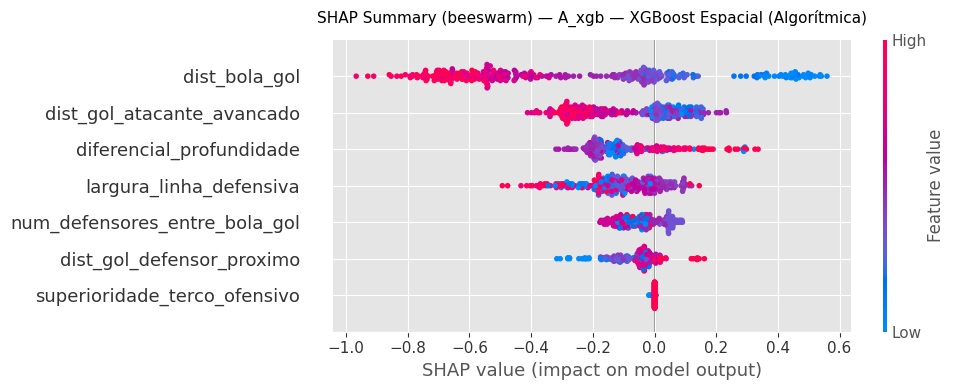

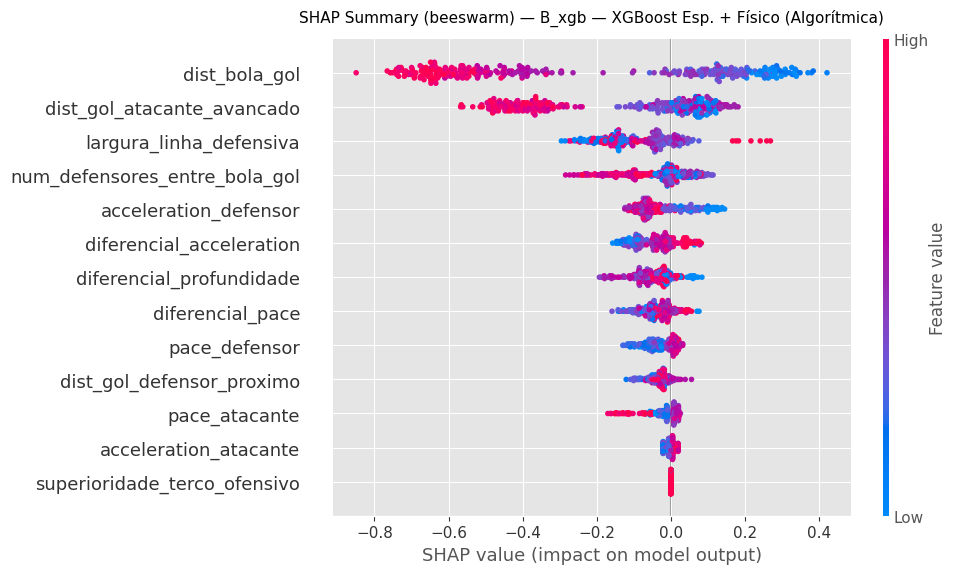

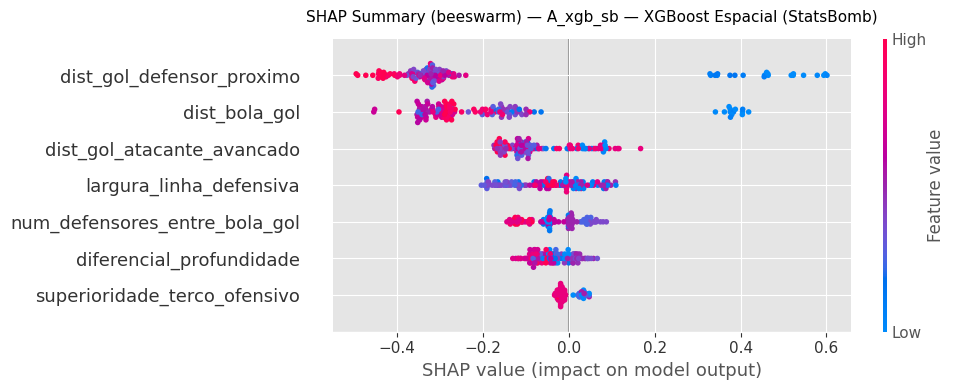

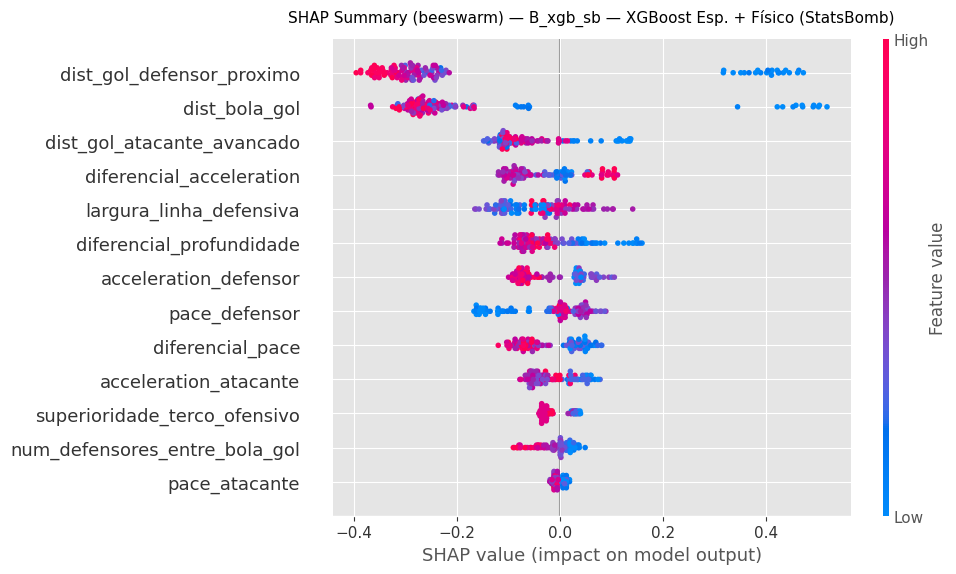

In [172]:
# 10.3 — Summary plots (beeswarm): direção e magnitude dos SHAP values
# Cada ponto é uma observação; cor = valor da feature (vermelho = alto, azul = baixo)

modelos_shap = [
    ('A_xgb — XGBoost Espacial (Algorítmica)',         sv_Axgb, df_Axgb),
    ('B_xgb — XGBoost Esp. + Físico (Algorítmica)',    sv_Bxgb, df_Bxgb),
    ('A_xgb_sb — XGBoost Espacial (StatsBomb)',        sv_A_sb, df_A_sb),
    ('B_xgb_sb — XGBoost Esp. + Físico (StatsBomb)',   sv_B_sb, df_B_sb),
]

for titulo, sv, df_display in modelos_shap:
    n_feat = df_display.shape[1]
    shap.summary_plot(
        sv, df_display,
        max_display=n_feat,
        show=False,
    )
    plt.title(f'SHAP Summary (beeswarm) — {titulo}', fontsize=11, pad=12)
    plt.gcf().set_size_inches(10, max(4, n_feat * 0.45))
    plt.tight_layout()
    plt.show()


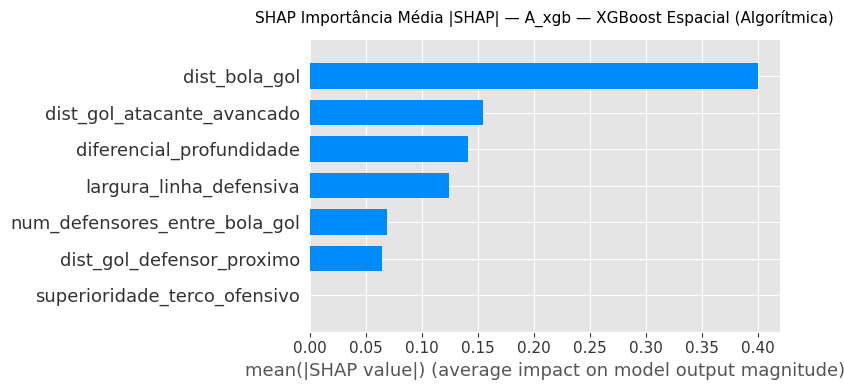

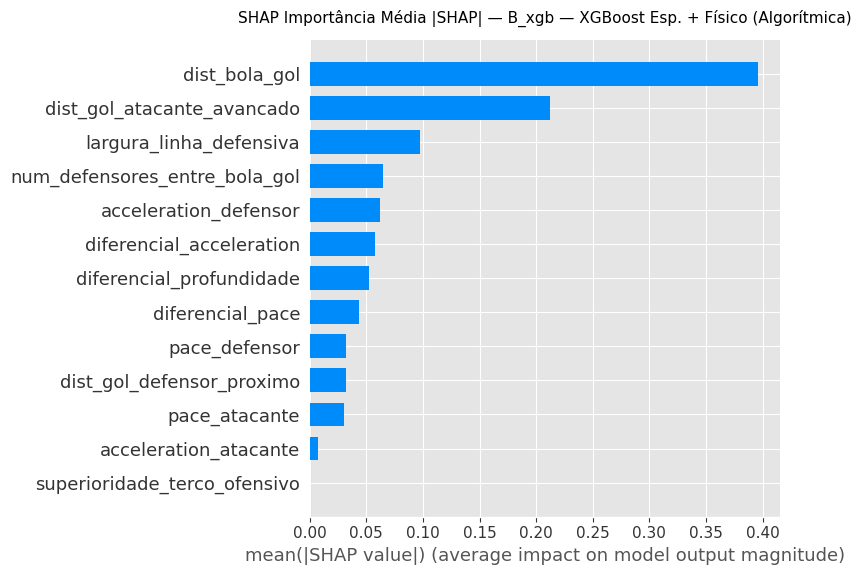

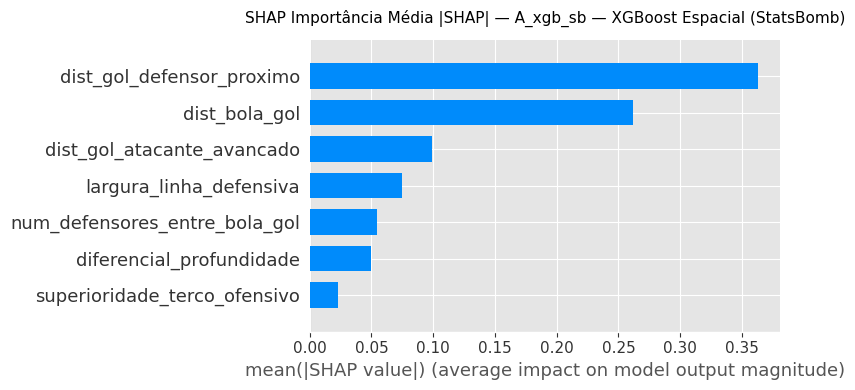

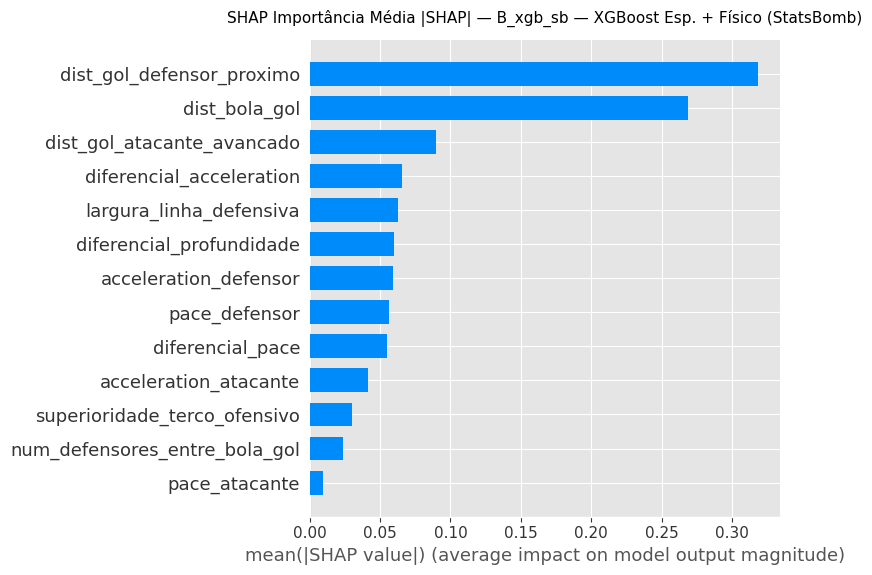

In [173]:
# 10.4 — Bar plots: importância média |SHAP| por feature
# Mostra magnitude agregada — equivalente à importância global do modelo

for titulo, sv, df_display in modelos_shap:
    n_feat = df_display.shape[1]
    shap.summary_plot(
        sv, df_display,
        plot_type='bar',
        max_display=n_feat,
        show=False,
    )
    plt.title(f'SHAP Importância Média |SHAP| — {titulo}', fontsize=11, pad=12)
    plt.gcf().set_size_inches(8, max(4, n_feat * 0.45))
    plt.tight_layout()
    plt.show()


In [174]:
# 10.5 — Tabela consolidada: top-5 features por modelo (ranking SHAP)

def top5_shap(sv, features, k=5):
    mean_abs = np.abs(sv).mean(axis=0)
    df = pd.DataFrame({'feature': features, 'mean_abs': mean_abs})
    df = df.sort_values('mean_abs', ascending=False).reset_index(drop=True)
    return df.head(k)

rank_Axgb = top5_shap(sv_Axgb, FEATURES_ESPACIAIS)
rank_Bxgb = top5_shap(sv_Bxgb, FEATURES_B_XGB)
rank_A_sb = top5_shap(sv_A_sb, FEATURES_ESPACIAIS)
rank_B_sb = top5_shap(sv_B_sb, FEATURES_B_XGB_SB)

W = 120
print('=' * W)
print('Top-5 Features por Importância SHAP Média (|SHAP|)')
print('=' * W)
print(f'{"Rank":<6}{"A_xgb (alg.)":<30}{"B_xgb (alg.)":<30}{"A_xgb_sb (SB)":<30}{"B_xgb_sb (SB)"}')
print('-' * W)
for i in range(5):
    fA   = rank_Axgb.iloc[i]['feature']   if i < len(rank_Axgb) else '-'
    sA   = rank_Axgb.iloc[i]['mean_abs']  if i < len(rank_Axgb) else 0
    fB   = rank_Bxgb.iloc[i]['feature']   if i < len(rank_Bxgb) else '-'
    sB   = rank_Bxgb.iloc[i]['mean_abs']  if i < len(rank_Bxgb) else 0
    fAsb = rank_A_sb.iloc[i]['feature']   if i < len(rank_A_sb) else '-'
    sAsb = rank_A_sb.iloc[i]['mean_abs']  if i < len(rank_A_sb) else 0
    fBsb = rank_B_sb.iloc[i]['feature']   if i < len(rank_B_sb) else '-'
    sBsb = rank_B_sb.iloc[i]['mean_abs']  if i < len(rank_B_sb) else 0
    print(f'{i+1:<6}'
          f'{fA:<22} ({sA:.4f})  '
          f'{fB:<22} ({sB:.4f})  '
          f'{fAsb:<22} ({sAsb:.4f})  '
          f'{fBsb:<22} ({sBsb:.4f})')
print('=' * W)


Top-5 Features por Importância SHAP Média (|SHAP|)
Rank  A_xgb (alg.)                  B_xgb (alg.)                  A_xgb_sb (SB)                 B_xgb_sb (SB)
------------------------------------------------------------------------------------------------------------------------
1     dist_bola_gol          (0.3999)  dist_bola_gol          (0.3957)  dist_gol_defensor_proximo (0.3627)  dist_gol_defensor_proximo (0.3182)
2     dist_gol_atacante_avancado (0.1543)  dist_gol_atacante_avancado (0.2126)  dist_bola_gol          (0.2614)  dist_bola_gol          (0.2685)
3     diferencial_profundidade (0.1417)  largura_linha_defensiva (0.0973)  dist_gol_atacante_avancado (0.0990)  dist_gol_atacante_avancado (0.0894)
4     largura_linha_defensiva (0.1242)  num_defensores_entre_bola_gol (0.0646)  largura_linha_defensiva (0.0748)  diferencial_acceleration (0.0658)
5     num_defensores_entre_bola_gol (0.0689)  acceleration_defensor  (0.0624)  num_defensores_entre_bola_gol (0.0548)  largura_linha_d

In [175]:
# 10.6 — Features físicas nos modelos B: posição no ranking SHAP vs importância nativa

FEATURES_FISICAS = [
    'pace_atacante', 'acceleration_atacante',
    'pace_defensor', 'acceleration_defensor',
    'diferencial_pace', 'diferencial_acceleration',
]

def analisa_fisicas(sv, features, nome_modelo):
    mean_abs = np.abs(sv).mean(axis=0)
    df = pd.DataFrame({'feature': features, 'mean_abs_shap': mean_abs})
    df = df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    df['rank_shap'] = df.index + 1
    total = len(df)

    print(f'\n{"="*65}')
    print(f'Modelo {nome_modelo}  —  {total} features')
    print(f'{"="*65}')
    print(f'  {"Feature":<35} {"Rank":>5}  {"Mean|SHAP|":>10}  Tipo')
    print(f'  {"-"*60}')
    for _, row in df.iterrows():
        eh_fisica = row['feature'] in FEATURES_FISICAS
        tipo = 'FÍSICA  ◄' if eh_fisica else 'espacial'
        print(f'  {row["feature"]:<35} {row["rank_shap"]:>5}  {row["mean_abs_shap"]:>10.4f}  {tipo}')

    fisicas_df = df[df['feature'].isin(FEATURES_FISICAS)]
    fisicas_ranks = sorted(fisicas_df['rank_shap'].tolist())
    print(f'\n  Features físicas: posições {fisicas_ranks} de {total}')

    # Comparar com feature_importances_ nativa do XGBoost
    # Os modelos são pipelines; acessar o passo 'xgb'
    return df

print('=== Análise de Features Físicas — Modelos B ===')
df_rank_Bxgb = analisa_fisicas(sv_Bxgb,  FEATURES_B_XGB,    'B_xgb (algorítmico)')
df_rank_Bsb  = analisa_fisicas(sv_B_sb,   FEATURES_B_XGB_SB, 'B_xgb_sb (StatsBomb)')

# Comparação direta: top feature de cada modelo B
top_Bxgb = df_rank_Bxgb.iloc[0]['feature']
top_Bsb  = df_rank_Bsb.iloc[0]['feature']
print(f'\n► Feature mais importante B_xgb   : {top_Bxgb}')
print(f'► Feature mais importante B_xgb_sb: {top_Bsb}')

# Features físicas presentes no top-3 de cada modelo B?
top3_Bxgb = set(df_rank_Bxgb.head(3)['feature'])
top3_Bsb  = set(df_rank_Bsb.head(3)['feature'])
fisicas_top3_Bxgb = top3_Bxgb & set(FEATURES_FISICAS)
fisicas_top3_Bsb  = top3_Bsb  & set(FEATURES_FISICAS)
print(f'\n► Físicas no top-3 de B_xgb   : {fisicas_top3_Bxgb if fisicas_top3_Bxgb else "nenhuma"}')
print(f'► Físicas no top-3 de B_xgb_sb: {fisicas_top3_Bsb  if fisicas_top3_Bsb  else "nenhuma"}')


=== Análise de Features Físicas — Modelos B ===

Modelo B_xgb (algorítmico)  —  13 features
  Feature                              Rank  Mean|SHAP|  Tipo
  ------------------------------------------------------------
  dist_bola_gol                           1      0.3957  espacial
  dist_gol_atacante_avancado              2      0.2126  espacial
  largura_linha_defensiva                 3      0.0973  espacial
  num_defensores_entre_bola_gol           4      0.0646  espacial
  acceleration_defensor                   5      0.0624  FÍSICA  ◄
  diferencial_acceleration                6      0.0576  FÍSICA  ◄
  diferencial_profundidade                7      0.0524  espacial
  diferencial_pace                        8      0.0432  FÍSICA  ◄
  pace_defensor                           9      0.0322  FÍSICA  ◄
  dist_gol_defensor_proximo              10      0.0317  espacial
  pace_atacante                          11      0.0299  FÍSICA  ◄
  acceleration_atacante                  12      0.0